<a href="https://colab.research.google.com/github/vijaybsbs/Delhivery-Business-Case-Study---Feature-Engineering/blob/main/Delhivery_Business_Case_Study_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">
                <font color="red" size="6">
                    <b>Delhivery Business Case Study - Feature Engineering </b>

# **Delhivery Introduction**

Delhivery is the largest and fastest growing fully integrated player in India by revenue in Fiscal 2021. They aim to build the operating system for commerce, through a combination of world-class infrastructure, logistics operations of the highest quality and cutting-edge engineering and technology capabilities.

The Data team builds intelligence and capabilities using this data that helps them to widen the gap between the quality, efficiency and profitability of their business versus their competitors.

# **How can you help here?**

The company wants to understand and process the data coming out of data engineering pipelines

• Clean, sanitize and manipulate data to get useful features out of raw fields:

• Make sense out of the raw data and help data science team to build forecasting models on it

## **Dataset**

Column Profiling:

data - tells whether the data is testing or training data
trip_creation_time – Timestamp of trip creation
route_schedule_uuid – Unique ID for a particular route schedule
route_type – Transportation type

a. FTL – Full Truck Load: FTL shipments get to the destination sooner, as the truck is making no other pickups or drop-offs along the way

b. Carting: Handling system consisting of small vehicles (carts)

trip_uuid - Unique ID given to a particular trip (A trip may include different source and destination centers)
source_center - Source ID of trip origin
source_name - Source Name of trip origin
destination_cente – Destination ID
destination_name – Destination Name
od_start_time – Trip start time
od_end_time – Trip end time
start_scan_to_end_scan – Time taken to deliver from source to destination
is_cutoff – Unknown field
cutoff_factor – Unknown field
cutoff_timestamp – Unknown field
actual_distance_to_destination – Distance in kms between source and destination warehouse
actual_time – Actual time taken to complete the delivery (Cumulative)
osrm_time – An open-source routing engine time calculator which computes the shortest path between points in a given map (Includes usual traffic, distance through major and minor roads) and gives the time (Cumulative)
osrm_distance – An open-source routing engine which computes the shortest path between points in a given map (Includes usual traffic, distance through major and minor roads) (Cumulative)
factor – Unknown field
segment_actual_time – This is a segment time. Time taken by the subset of the package delivery
segment_osrm_time – This is the OSRM segment time. Time taken by the subset of the package delivery
segment_osrm_distance – This is the OSRM distance. Distance covered by subset of the package delivery
segment_factor – Unknown field

# **Importing Libraries & Data**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/551/original/delhivery_data.csv?1642751181')

In [3]:
df.head(5)

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


# **Exploratory Data Analysis**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [5]:
df.isna().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,293
destination_center,0
destination_name,261
od_start_time,0


**Dropping Unknown fields**

In [6]:
df1 = df
unknown_fields = ['is_cutoff', 'cutoff_factor', 'cutoff_timestamp','factor', 'segment_factor']
df1 = df1.drop(columns = unknown_fields)

In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 19 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  actual_distance_

**Time Period of the given Data**

In [8]:
df1['trip_creation_time'].min(), df1['od_end_time'].max()

('2018-09-12 00:00:16.535741', '2018-10-08 03:00:24.353479')

In [9]:
df1.nunique()

,0
data,2
trip_creation_time,14817
route_schedule_uuid,1504
route_type,2
trip_uuid,14817
source_center,1508
source_name,1498
destination_center,1481
destination_name,1468
od_start_time,26369


In [10]:
df1.duplicated().value_counts()

,count
False,144867


## **Insights**

**1. Missing Value Handling**

* The dataset contains **144,867 records**.
* Only two columns have missing values:

  * `source_name` – **293** missing values.
  * `destination_name` – **261** missing values.
* Since these missing values account for **less than 0.3%** of the dataset, they have minimal impact on the analysis and can be handled appropriately during preprocessing.

**2. Dropping Unnecessary Features**
The following columns were removed because they are either intermediate calculations or operational flags that do not add value to the analysis:

* `is_cutoff`
* `cutoff_factor`
* `cutoff_timestamp`
* `factor`
* `segment_factor`

This simplifies the dataset and reduces unnecessary complexity.

**3. Data Coverage**

* The shipment data spans from **12 September 2018** to **8 October 2018**, covering approximately **27 days** of logistics operations.
* This period is sufficient to analyze shipment movement and operational performance.

**4. Unique Values**

* There are **14,817 unique trips** (`trip_uuid`), indicating each trip is uniquely identified.
* The dataset includes over **1,500 logistics centers**, showing a wide distribution of source and destination hubs.
* Continuous variables such as distance and travel time have a large number of unique values, making them useful for predictive modeling.

**5. Duplicate Records**

* No duplicate records were found in the dataset.
* This indicates good data quality and no additional duplicate removal was required.


**Category Conversion**

In [11]:
df1['data'] = df1['data'].astype('category')
df1['route_type'] = df1['route_type'].astype('category')

# **Basic Cleaning**

In [12]:
datetime_cols = [
    "trip_creation_time",
    "od_start_time",
    "od_end_time"
]

for col in datetime_cols:
    df1[col] = pd.to_datetime(df1[col], errors="coerce")

In [13]:
duration_cols = [
    "actual_time",
    "osrm_time",
    "segment_actual_time",
    "segment_osrm_time",
]

for col in duration_cols:
    df1[col] = pd.to_numeric(df1[col], errors="coerce")

In [14]:
numeric_cols = [
    "start_scan_to_end_scan",
    "actual_distance_to_destination",
    "osrm_distance",
    "segment_osrm_distance"
]

for col in numeric_cols:
    df1[col] = pd.to_numeric(df1[col], errors="coerce")

# **Fill Missing Values:**

In [15]:
for col in df1.columns:
    if df1[col].isna().any():
        if df1[col].dtype == "object":
            df1[col] = df1[col].fillna(df1[col].mode()[0])
        else:
            df1[col] = df1[col].fillna(df1[col].median())

In [16]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 19 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   data                            144867 non-null  category      
 1   trip_creation_time              144867 non-null  datetime64[ns]
 2   route_schedule_uuid             144867 non-null  object        
 3   route_type                      144867 non-null  category      
 4   trip_uuid                       144867 non-null  object        
 5   source_center                   144867 non-null  object        
 6   source_name                     144867 non-null  object        
 7   destination_center              144867 non-null  object        
 8   destination_name                144867 non-null  object        
 9   od_start_time                   144867 non-null  datetime64[ns]
 10  od_end_time                     144867 non-null  datetim

In [17]:
df1.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
data,144867,2,training,104858,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trip_creation_time,144867,NaN,NaN,NaN,2018-09-22 13:34:23.659819264,2018-09-12 00:00:16.535741,2018-09-17 03:20:51.775845888,2018-09-22 04:24:27.932764928,2018-09-27 17:57:56.350054912,2018-10-03 23:59:42.701692,NaN
route_schedule_uuid,144867,1504,thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069f...,1812,NaN,NaN,NaN,NaN,NaN,NaN,NaN
route_type,144867,2,FTL,99660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trip_uuid,144867,14817,trip-153759210483476123,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_center,144867,1508,IND000000ACB,23347,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_name,144867,1498,Gurgaon_Bilaspur_HB (Haryana),23640,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_center,144867,1481,IND000000ACB,15192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_name,144867,1468,Gurgaon_Bilaspur_HB (Haryana),15453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
od_start_time,144867,NaN,NaN,NaN,2018-09-22 18:02:45.855230720,2018-09-12 00:00:16.535741,2018-09-17 08:05:40.886155008,2018-09-22 08:53:00.116656128,2018-09-27 22:41:50.285857024,2018-10-06 04:27:23.392375,NaN


In [18]:
df1.describe(include= 'category')

,data,route_type
count,144867,144867
unique,2,2
top,training,FTL
freq,104858,99660


**Insights**

### 1. Categorical Data Conversion

* The `data` and `route_type` columns were converted to the **category** data type.
* This reduces memory usage and improves the efficiency of data processing since these columns contain a limited number of unique values.

### 2. Datetime Conversion

* The columns `trip_creation_time`, `od_start_time`, and `od_end_time` were converted from **object** to **datetime** format.
* This enables time-based analysis such as trip duration, daily shipment trends, and operational performance over time.

### 3. Numeric Data Conversion

* Duration-related columns (`actual_time`, `osrm_time`, `segment_actual_time`, `segment_osrm_time`) were converted to numeric values.
* Distance-related columns (`start_scan_to_end_scan`, `actual_distance_to_destination`, `osrm_distance`, `segment_osrm_distance`) were also converted to numeric format.
* Using `errors='coerce'` ensures that any invalid values are converted to `NaN`, improving data quality for further analysis.

### 4. Missing Value Treatment

* Missing values in categorical columns were replaced with the **most frequent (mode)** value.
* Missing values in numerical columns were replaced with the **median**, which is less affected by extreme values than the mean.
* After preprocessing, **all 144,867 records contain complete data with no missing values.**

### 5. Final Dataset Structure

* The cleaned dataset contains:

  * **144,867 observations**
  * **19 features**
* Data types include:

  * **2 categorical columns**
  * **3 datetime columns**
  * **8 numerical columns**
  * **6 object (text) columns**

### 6. Summary Statistics

* The dataset consists of **14,817 unique trips** executed over a period of approximately **27 days**.
* The average **actual trip time** is **417 minutes**, while the average **OSRM estimated time** is **214 minutes**, indicating that actual trips generally take longer than the estimated route time.
* The average **actual distance to destination** is **234 km**, whereas the average **OSRM estimated distance** is **285 km**.
* The median actual trip time is **132 minutes**, showing that a few long-duration trips increase the overall average.
* Segment-level travel time has a median of **29 minutes**, suggesting that most shipment segments are completed within a relatively short duration.


**Univarient Analysis**

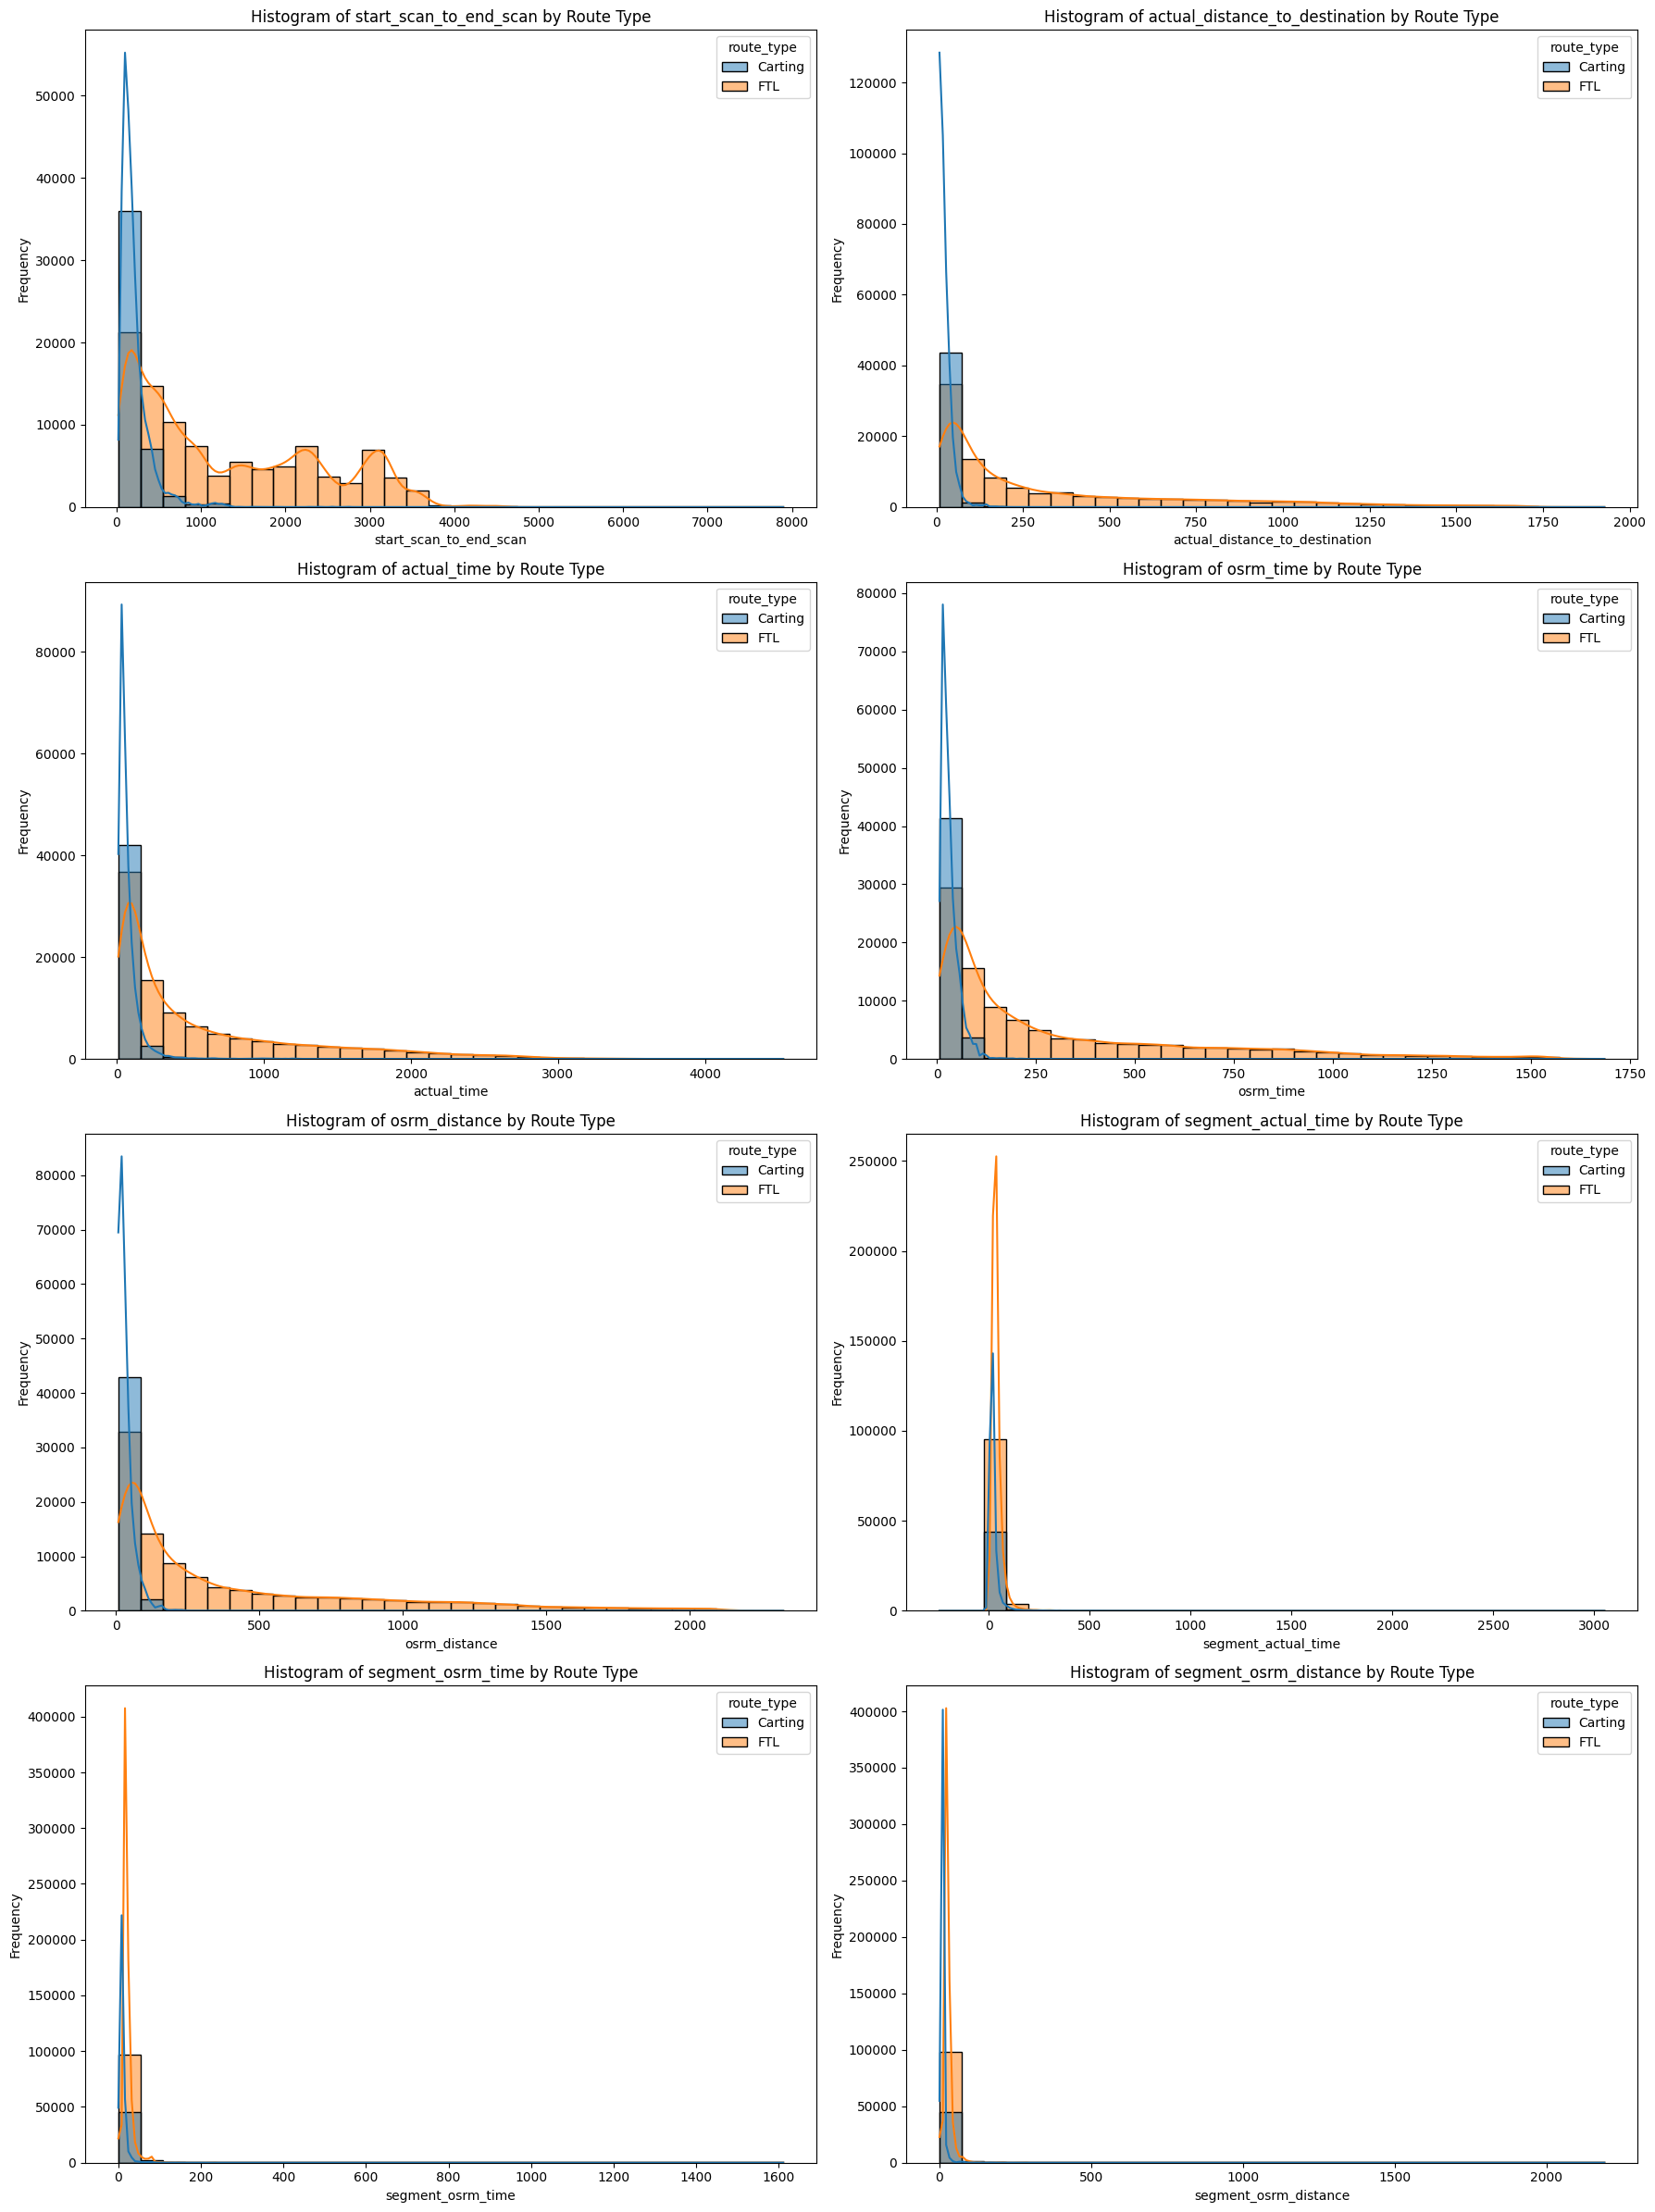

In [19]:
continuous_cols = [
    "start_scan_to_end_scan",
    "actual_distance_to_destination",
    "actual_time",
    "osrm_time",
    "osrm_distance",
    "segment_actual_time",
    "segment_osrm_time",
    "segment_osrm_distance"
]

fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.histplot(data=df1, x=col, hue='route_type', bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Histogram of {col} by Route Type")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Insights**

## 1. `start_scan_to_end_scan`

* Both **FTL** and **Carting** distributions are positively skewed.
* **Carting** trips are concentrated at lower scan durations.
* **FTL** trips have a wider spread, indicating longer scan-to-scan durations for many shipments.

## 2. `actual_distance_to_destination`

* Most **Carting** shipments travel short distances.
* **FTL** shipments cover a much wider range of distances, including many long-distance deliveries.
* This suggests that FTL is mainly used for longer transportation routes.

## 3. `actual_time`

* **Carting** trips generally have shorter actual travel times.
* **FTL** trips show a broader distribution with longer travel times.
* Longer travel times for FTL are expected because they usually cover greater distances.

## 4. `osrm_time`

* The estimated travel time follows a similar pattern to actual travel time.
* **Carting** routes have lower estimated travel times.
* **FTL** routes have higher estimated travel times due to longer routes.

## 5. `osrm_distance`

* **Carting** routes are mostly short-distance deliveries.
* **FTL** routes include many medium and long-distance shipments.
* The estimated route distance aligns with the operational differences between the two route types.

## 6. `segment_actual_time`

* Most shipment segments for both route types are completed in a short duration.
* **FTL** segments show slightly greater variation than Carting.
* A few long-duration segment outliers are present in both categories.

## 7. `segment_osrm_time`

* Estimated segment travel times are concentrated at lower values for both route types.
* The distributions of FTL and Carting are quite similar at the segment level.
* Only a few segments have very high estimated travel times.

## 8. `segment_osrm_distance`

* Most shipment segments cover short distances regardless of route type.
* FTL has slightly more long-distance segment estimates than Carting.
* Overall, segment-level distances remain relatively small compared to total trip distances.

# Overall Observation

* Both **FTL** and **Carting** variables are **positively (right) skewed**, with most observations concentrated at lower values.
* **Carting** is primarily used for **short-distance and shorter-duration deliveries**.
* **FTL** is associated with **longer distances and longer travel times**, making it suitable for inter-city or long-haul transportation.
* At the **segment level**, the differences between FTL and Carting are much smaller, indicating that long trips are divided into multiple shorter segments during transportation.


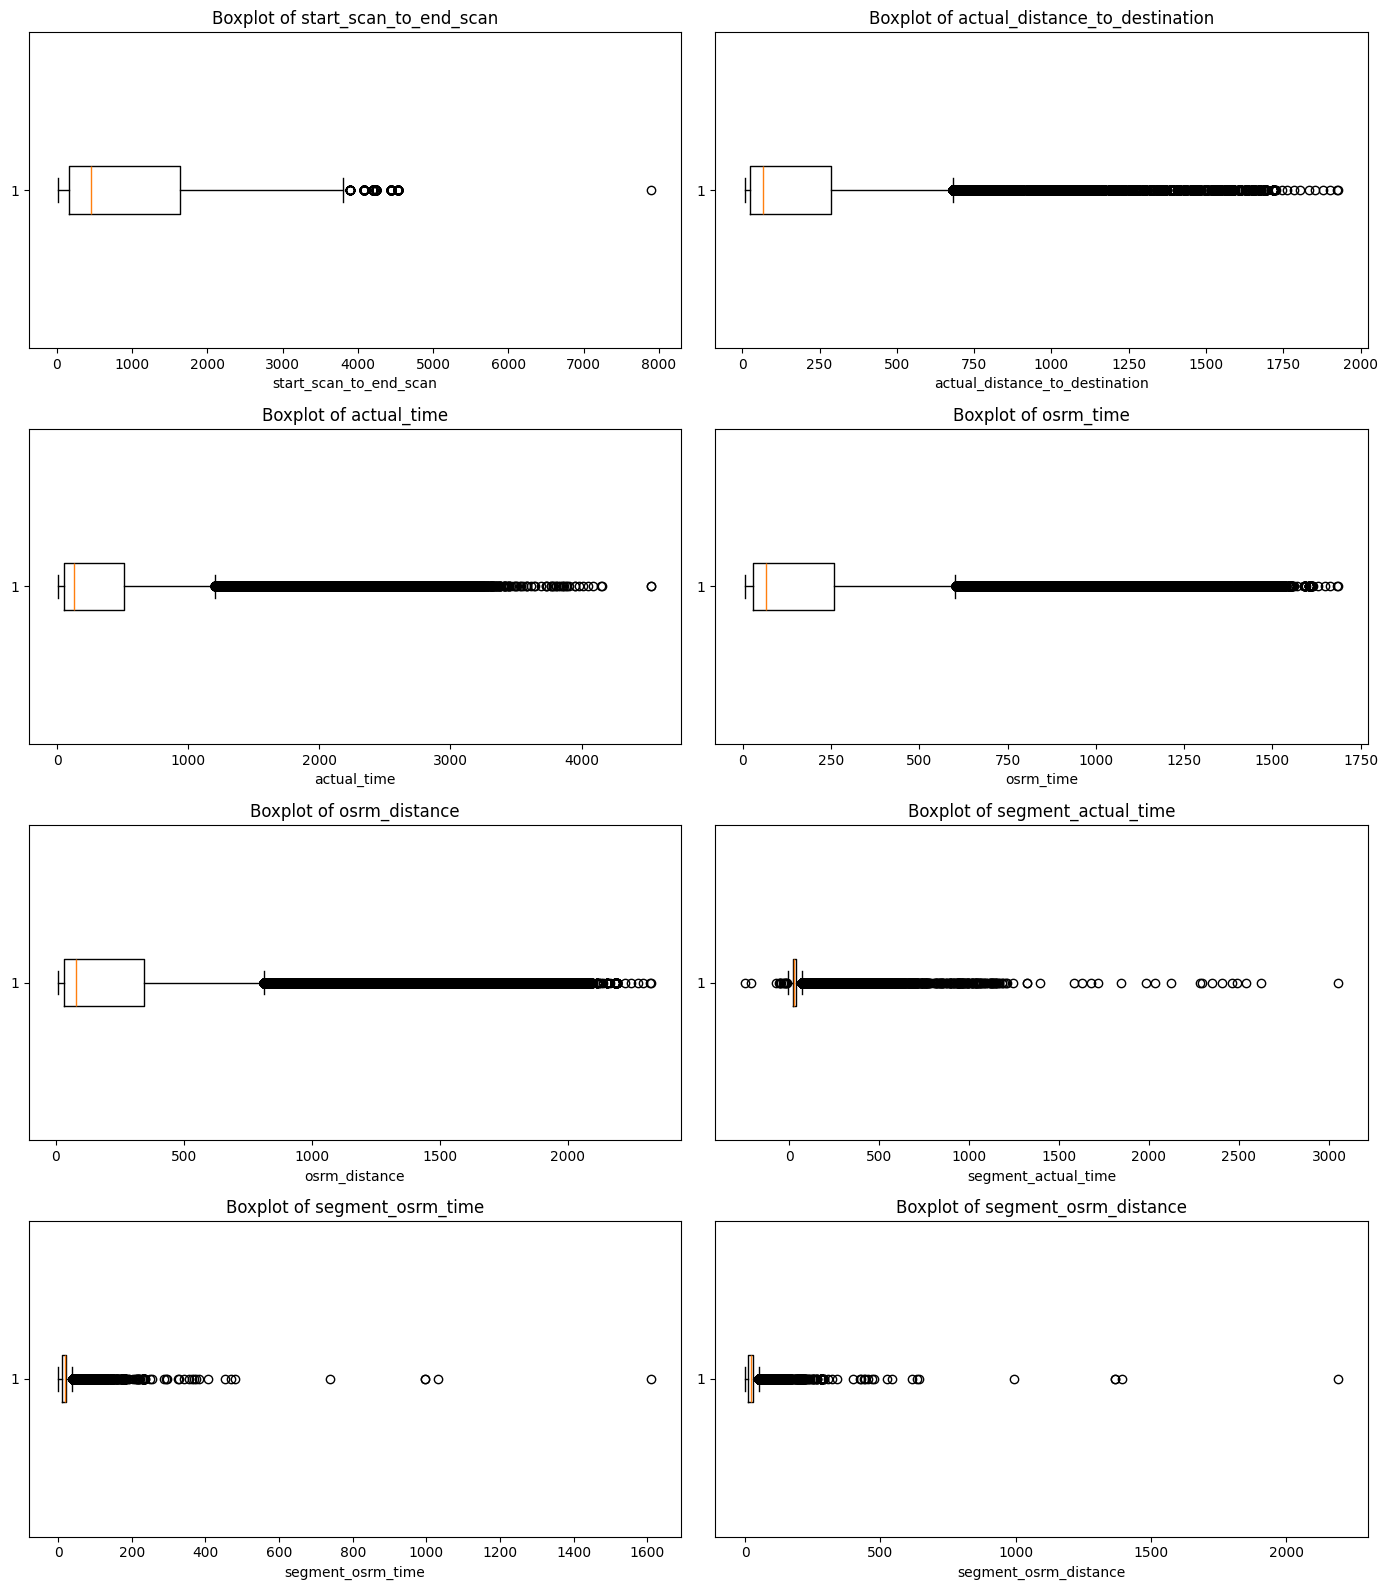

In [20]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].boxplot(df1[col], vert=False)
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

**Insights**

## 1. `start_scan_to_end_scan`

* The boxplot shows several **outliers** on the higher end.
* Most shipments have scan durations within a relatively small range, but a few shipments take significantly longer.
* The distribution is **positively skewed**.

## 2. `actual_distance_to_destination`

* There are **many outliers** representing long-distance deliveries.
* Most shipments travel relatively short distances.
* The wide spread of outliers indicates a diverse delivery network covering both local and long-distance shipments.

## 3. `actual_time`

* The actual trip time contains a **large number of outliers**.
* Most deliveries are completed within a moderate time range, while a few trips take much longer.
* These outliers may be due to traffic, weather, operational delays, or long-distance routes.

## 4. `osrm_time`

* Similar to actual time, the estimated travel time also has **many outliers**.
* Most estimated travel times are relatively low, with only a few extremely long estimated trips.
* The distribution remains positively skewed.

## 5. `osrm_distance`

* The estimated route distance contains **numerous high-value outliers**.
* Most routes are short to medium distance.
* A few routes cover very long distances across the logistics network.

## 6. `segment_actual_time`

* Most shipment segments are completed quickly.
* The boxplot shows **many extreme outliers**, indicating that some segments experience unusually long travel times.
* A few observations are even below zero, which may indicate data quality issues or recording errors that require further investigation.

## 7. `segment_osrm_time`

* The estimated segment travel time has relatively fewer outliers compared to actual segment time.
* Most segment travel times are concentrated within a small range.
* A few very high estimated values exist for longer shipment segments.

## 8. `segment_osrm_distance`

* Most shipment segments cover short distances.
* The boxplot shows several outliers corresponding to long-distance shipment segments.
* The majority of deliveries are concentrated within a narrow distance range.


## Overall Observation

* **All continuous variables contain outliers**, which is common in logistics datasets due to variations in delivery distance, traffic conditions, and shipment routes.
* Most variables are **positively skewed**, with the majority of observations concentrated at lower values and a small number of extremely high values.


In [21]:
df1["od_start_hour"] = df1["od_start_time"].dt.hour
df1["od_end_hour"] = df1["od_end_time"].dt.hour

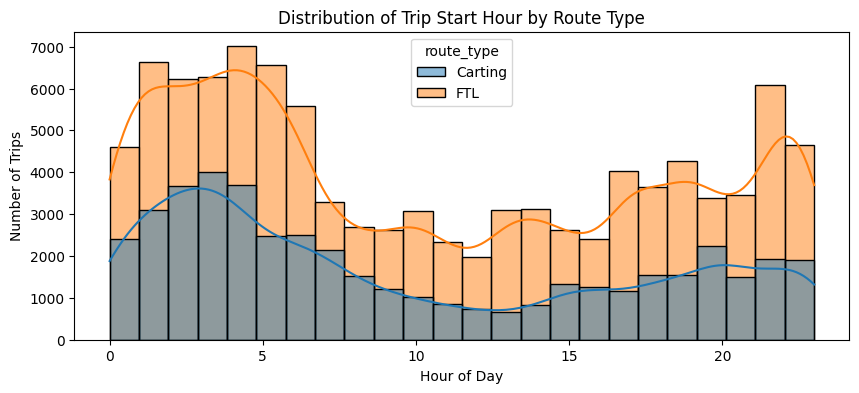

In [22]:
plt.figure(figsize=(10,4))
sns.histplot(data=df1, x="od_start_hour", hue="route_type", bins=24, kde=True)
plt.title("Distribution of Trip Start Hour by Route Type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

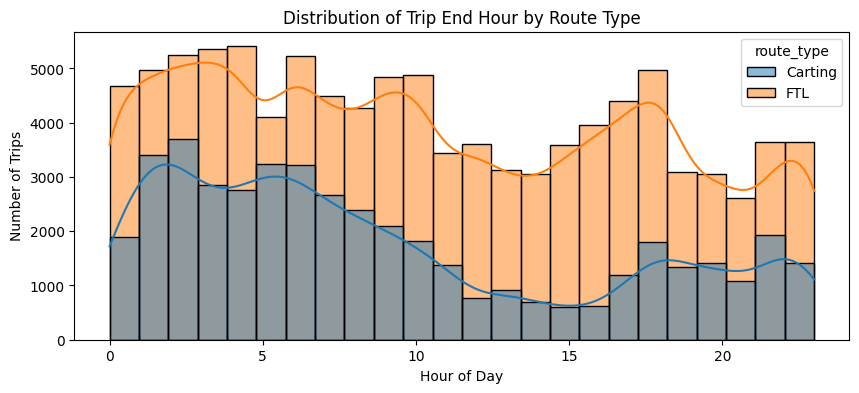

In [23]:
plt.figure(figsize=(10,4))
sns.histplot(data=df1, x="od_end_hour", hue="route_type", bins=24, kde=True)
plt.title("Distribution of Trip End Hour by Route Type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

**Insights**

# 1. Distribution of Trip Start Hour by Route Type

* Both **FTL** and **Carting** operations run **24 hours a day**.
* **FTL** has a higher number of trips than Carting across almost all hours of the day.
* Both route types show the highest number of trip starts during the **early morning hours (around 2 AM to 5 AM)**.
* Trip starts decrease during the **afternoon (around 11 AM to 3 PM)** for both route types.
* Another increase in trip starts is observed during the **evening and late-night hours (around 5 PM to 11 PM)**.
* This indicates that Delhivery schedules a significant portion of both FTL and Carting trips during **night and early morning** to improve operational efficiency.

# 2. Distribution of Trip End Hour by Route Type

* Both **FTL** and **Carting** trips end throughout the day, showing continuous logistics operations.
* **FTL** consistently records more trip completions than Carting across all hours.
* The highest number of trip completions occurs during the **early morning hours (around 1 AM to 6 AM)**.
* Trip completions reduce during the **afternoon (around 12 PM to 3 PM)**.
* A moderate increase in completed trips is observed during the **evening hours (around 4 PM to 6 PM)**.
* The similar patterns for both route types suggest coordinated scheduling of transportation and deliveries.

# Overall Observation

* Both **FTL** and **Carting** operate **24×7**, indicating round-the-clock logistics operations.
* **FTL** has a higher trip volume than Carting at almost every hour of the day.
* Peak trip starts and completions occur during the **night and early morning hours**, while activity is relatively lower during the afternoon.
* This scheduling pattern helps Delhivery optimize vehicle utilization and support timely deliveries across its logistics network.


**Bi-variant Analysis**

**Actual Time vs OSRM Time differentiated by route_type**

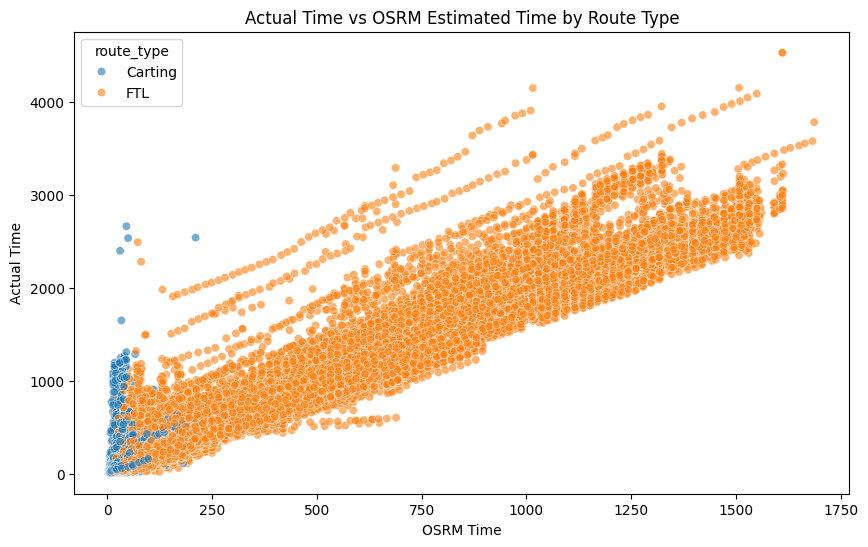

In [24]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="osrm_time", y="actual_time", hue="route_type", data=df1, alpha=0.6)
plt.title("Actual Time vs OSRM Estimated Time by Route Type")
plt.xlabel("OSRM Time")
plt.ylabel("Actual Time")
plt.show()

**Insights: Actual Time vs OSRM Estimated Time by Route Type**

* The scatter plot shows a **strong positive relationship** between **OSRM estimated time** and **actual travel time**. As the estimated time increases, the actual travel time also tends to increase.
* Most data points lie **above the ideal one-to-one relationship**, indicating that the **actual travel time is generally higher than the OSRM estimated time**. This suggests that the routing estimates may not fully account for real-world delays such as traffic, loading/unloading, or road conditions.
* **FTL (Full Truck Load)** shipments cover a much wider range of travel times and dominate the higher values, reflecting their long-distance nature.
* **Carting** shipments are mostly concentrated in the lower-left corner of the plot, indicating that they are generally **shorter trips with lower travel times**.
* The wider spread of FTL data points suggests **greater variability in actual travel times** compared to Carting, likely due to differences in route length and operational conditions.
* Overall, the chart indicates that while **OSRM provides a good estimate of travel time**, actual travel time is often higher, especially for long-distance FTL shipments.


**Actual Distance vs OSRM Distance**

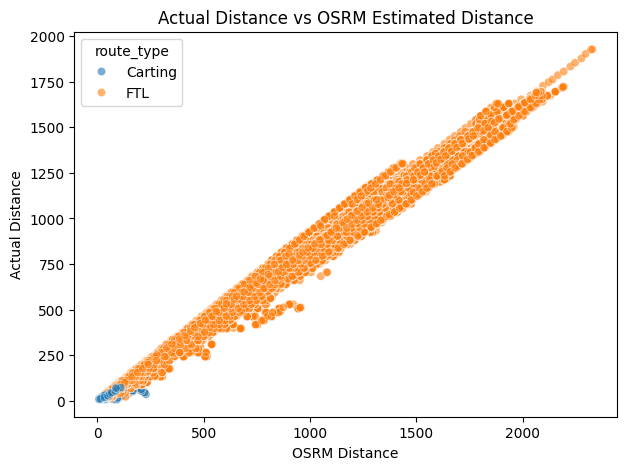

In [25]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="osrm_distance", y="actual_distance_to_destination", hue="route_type", data=df1, alpha=0.6)
plt.title("Actual Distance vs OSRM Estimated Distance")
plt.xlabel("OSRM Distance")
plt.ylabel("Actual Distance")
plt.show()

 **Insights: Actual Distance vs OSRM Estimated Distance by Route Type**

* The scatter plot shows a **strong positive linear relationship** between **OSRM estimated distance** and **actual travel distance**.
* Most data points lie very close to a straight diagonal pattern, indicating that the **OSRM estimated distance closely matches the actual distance traveled**.
* **FTL (Full Truck Load)** shipments cover a much wider range of distances, extending up to nearly **2,000 km**, reflecting long-distance transportation.
* **Carting** shipments are concentrated in the lower-left corner of the plot, indicating that they mainly handle **short-distance deliveries**.
* There are only a few points that deviate from the main pattern, suggesting that the estimated distances are generally accurate with very few exceptions.
* Overall, the chart indicates that **OSRM provides reliable distance estimates**, making it a useful tool for route planning and logistics operations.

**Route Type Distribution (FTL vs Carting)**

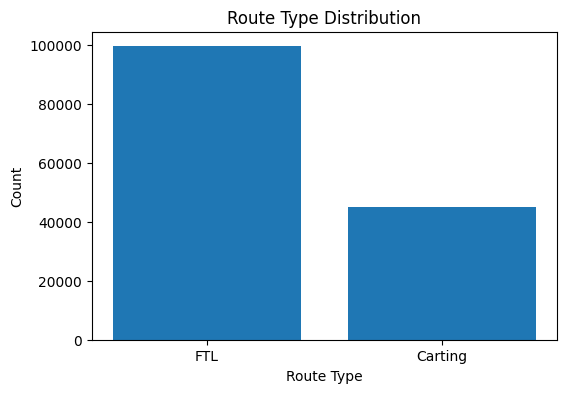

route_type
FTL        99660
Carting    45207
Name: count, dtype: int64


In [26]:
route_counts = df1["route_type"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(route_counts.index, route_counts.values)
plt.title("Route Type Distribution")
plt.xlabel("Route Type")
plt.ylabel("Count")
plt.show()

print(route_counts)

**Top 10 Source Locations**

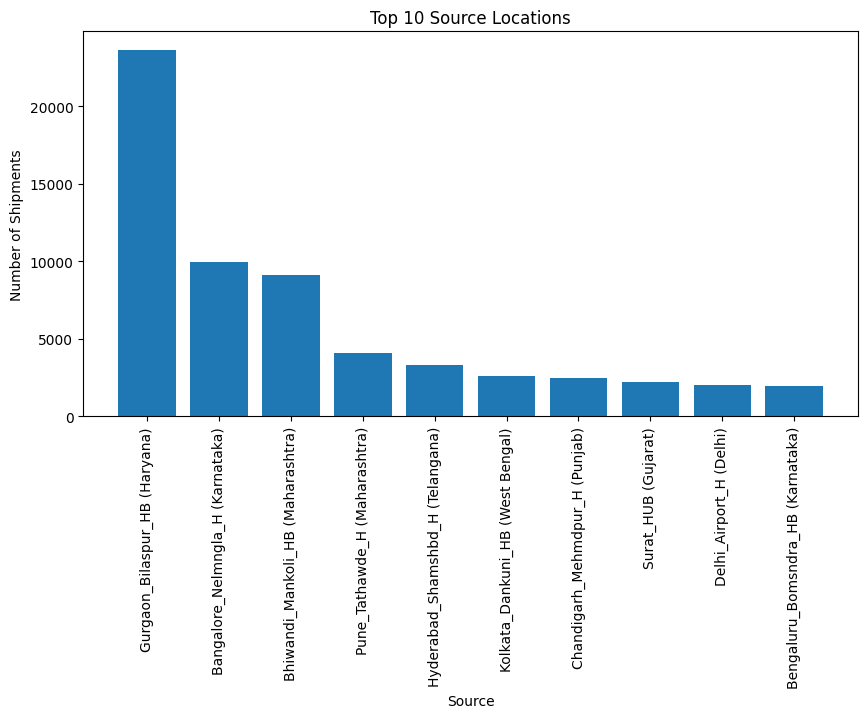

In [27]:
top_source = df1["source_name"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(top_source.index, top_source.values)
plt.xticks(rotation=90)
plt.title("Top 10 Source Locations")
plt.xlabel("Source")
plt.ylabel("Number of Shipments")
plt.show()

**Top 10 Destination Locations**

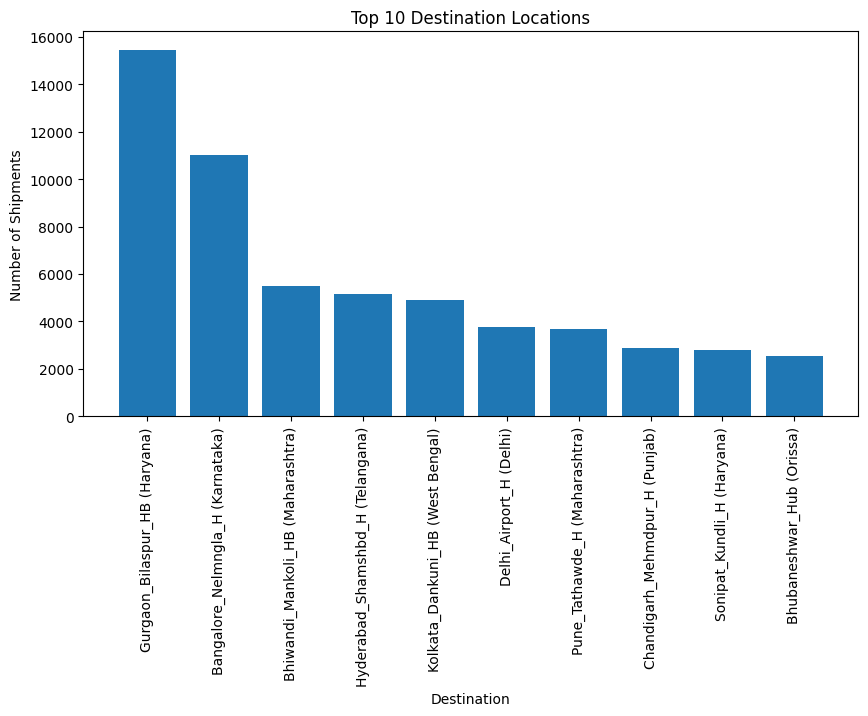

In [28]:
top_destination = df1["destination_name"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(top_destination.index, top_destination.values)
plt.xticks(rotation=90)
plt.title("Top 10 Destination Locations")
plt.xlabel("Destination")
plt.ylabel("Number of Shipments")
plt.show()

**Top Source States**

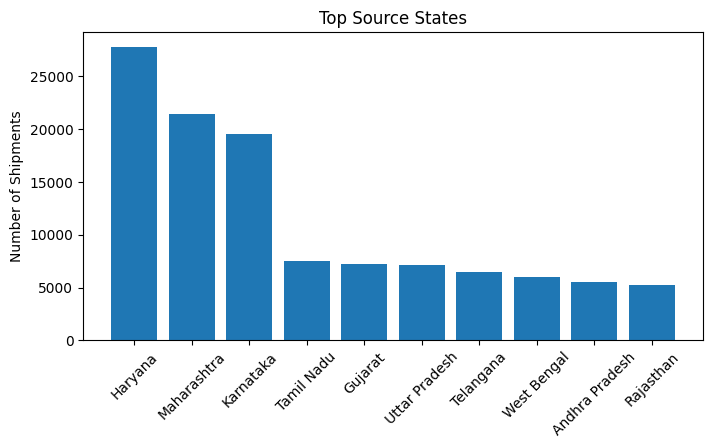

In [29]:
source_state = df1["source_name"].str.extract(r"\((.*?)\)")
source_state.columns = ["State"]

top_states = source_state["State"].value_counts().head(10)

plt.figure(figsize=(8,4))
plt.bar(top_states.index, top_states.values)
plt.title("Top Source States")
plt.xticks(rotation=45)
plt.ylabel("Number of Shipments")
plt.show()

**Top Destination States**

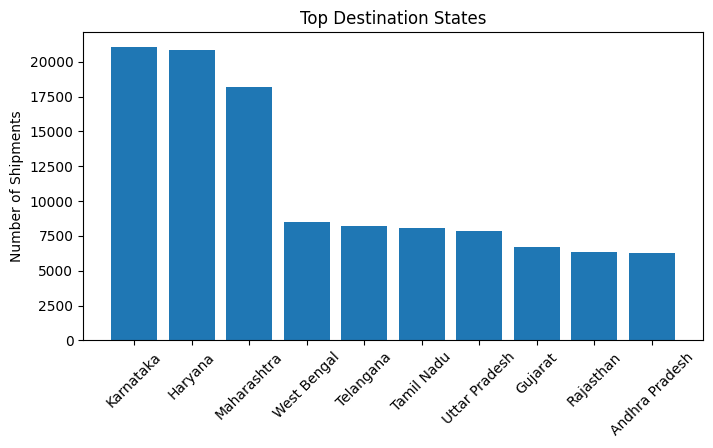

In [30]:
destination_state = df1["destination_name"].str.extract(r"\((.*?)\)")
destination_state.columns = ["State"]

top_dest_states = destination_state["State"].value_counts().head(10)

plt.figure(figsize=(8,4))
plt.bar(top_dest_states.index, top_dest_states.values)
plt.title("Top Destination States")
plt.xticks(rotation=45)
plt.ylabel("Number of Shipments")
plt.show()

# 1. Route Type Distribution

### Insights

* **FTL (Full Truck Load)** is the dominant route type in the dataset.
* FTL shipments are more than **twice** the number of Carting shipments.
* This indicates that Delhivery handles a larger proportion of long-haul or full-truck transportation compared to Carting.

# 2. Top 10 Source Locations

### Insights

* **Gurgaon_Bilaspur_HB (Haryana)** is the busiest source location, with the highest number of shipments.
* **Bangalore_Nelmangla_H (Karnataka)** and **Bhiwandi_Mankoli_HB (Maharashtra)** are the next busiest source hubs.
* The remaining locations contribute significantly fewer shipments, indicating that a few major hubs handle a large share of outbound shipments.

# 3. Top 10 Destination Locations

### Insights

* **Gurgaon_Bilaspur_HB (Haryana)** is also the top destination hub.
* **Bangalore_Nelmangla_H (Karnataka)** ranks second in terms of incoming shipments.
* Major logistics hubs such as **Bhiwandi**, **Hyderabad**, and **Kolkata** receive a high volume of deliveries.
* The shipment network is concentrated around a few major distribution centers.

# 4. Top Source States

### Insights

* **Haryana** is the leading source state, contributing the highest number of shipments.
* **Maharashtra** and **Karnataka** are the second and third largest source states.
* States such as **Tamil Nadu**, **Gujarat**, and **Uttar Pradesh** also contribute a significant number of shipments.
* This indicates that Delhivery has strong pickup operations in these major industrial and commercial states.

# 5. Top Destination States

### Insights

* **Karnataka** receives the highest number of shipments.
* **Haryana** and **Maharashtra** are the next largest destination states.
* **West Bengal**, **Telangana**, and **Tamil Nadu** also receive a substantial number of shipments.
* The destination distribution suggests that shipments are primarily delivered to major economic and metropolitan regions.

# Overall Observation

* **FTL** is the most commonly used route type in the dataset.
* A few major logistics hubs, particularly **Gurgaon (Haryana)**, **Bangalore (Karnataka)**, and **Bhiwandi (Maharashtra)**, account for a large share of shipment movement.
* **Haryana**, **Maharashtra**, and **Karnataka** are the key states for both shipment origins and destinations, highlighting them as major logistics centers in Delhivery's network.
* The shipment flow is concentrated around major industrial and metropolitan regions, indicating an efficient hub-and-spoke logistics model.


**Extract Features from destination_name**

In [31]:
df1["destination_city"] = df1["destination_name"].str.split("_").str[0]

df1["destination_state"] = df1["destination_name"].str.extract(r"\((.*?)\)")

df1[["destination_name", "destination_city", "destination_state"]].head(10)

,destination_name,destination_city,destination_state
0,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
1,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
2,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
3,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
4,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
5,Anand_Vaghasi_IP (Gujarat),Anand,Gujarat
6,Anand_Vaghasi_IP (Gujarat),Anand,Gujarat
7,Anand_Vaghasi_IP (Gujarat),Anand,Gujarat
8,Anand_Vaghasi_IP (Gujarat),Anand,Gujarat
9,Anand_Vaghasi_IP (Gujarat),Anand,Gujarat


**Extract Features from source_name**

In [32]:
df1["source_city"] = df1["source_name"].str.split("_").str[0]

df1["source_state"] = df1["source_name"].str.extract(r"\((.*?)\)")

df1[["source_name", "source_city", "source_state"]].head(10)

,source_name,source_city,source_state
0,Anand_VUNagar_DC (Gujarat),Anand,Gujarat
1,Anand_VUNagar_DC (Gujarat),Anand,Gujarat
2,Anand_VUNagar_DC (Gujarat),Anand,Gujarat
3,Anand_VUNagar_DC (Gujarat),Anand,Gujarat
4,Anand_VUNagar_DC (Gujarat),Anand,Gujarat
5,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
6,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
7,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
8,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
9,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat


**Extract Time-Based Features**

In [33]:
df1["trip_creation_time"] = pd.to_datetime(df1["trip_creation_time"])

In [34]:
df1["year"] = df1["trip_creation_time"].dt.year

df1["month"] = df1["trip_creation_time"].dt.month

df1["day"] = df1["trip_creation_time"].dt.day

df1["hour"] = df1["trip_creation_time"].dt.hour

df1["day_of_week"] = df1["trip_creation_time"].dt.day_name()

df1["week_number"] = df1["trip_creation_time"].dt.isocalendar().week

df1[[
    "trip_creation_time",
    "year",
    "month",
    "day",
    "hour",
    "day_of_week",
    "week_number"
]].head(10)

,trip_creation_time,year,month,day,hour,day_of_week,week_number
0,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday,38
1,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday,38
2,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday,38
3,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday,38
4,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday,38
5,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday,38
6,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday,38
7,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday,38
8,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday,38
9,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday,38


In [35]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   data                            144867 non-null  category      
 1   trip_creation_time              144867 non-null  datetime64[ns]
 2   route_schedule_uuid             144867 non-null  object        
 3   route_type                      144867 non-null  category      
 4   trip_uuid                       144867 non-null  object        
 5   source_center                   144867 non-null  object        
 6   source_name                     144867 non-null  object        
 7   destination_center              144867 non-null  object        
 8   destination_name                144867 non-null  object        
 9   od_start_time                   144867 non-null  datetime64[ns]
 10  od_end_time                     144867 non-null  datetim

In [36]:
df1.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,destination_city,destination_state,source_city,source_state,year,month,day,hour,day_of_week,week_number
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Khambhat,Gujarat,Anand,Gujarat,2018,9,20,2,Thursday,38
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Khambhat,Gujarat,Anand,Gujarat,2018,9,20,2,Thursday,38
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Khambhat,Gujarat,Anand,Gujarat,2018,9,20,2,Thursday,38
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Khambhat,Gujarat,Anand,Gujarat,2018,9,20,2,Thursday,38
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Khambhat,Gujarat,Anand,Gujarat,2018,9,20,2,Thursday,38


**Create segment_key**

A segment is uniquely identified by:

trip_uuid
source_center
destination_center

In [37]:
df1["segment_key"] = (
    df1["trip_uuid"] + "_" +
    df1["source_center"] + "_" +
    df1["destination_center"]
)
print("Total Rows:", len(df1))
print("Unique Segments:", df1["segment_key"].nunique())

Total Rows: 144867
Unique Segments: 26368


**Insight**

*A new column segment_key was created by combining trip_uuid, source_center, and destination_center.

*This uniquely identifies each shipment segment.

*The number of unique segment keys is lower than the total number of rows because each segment may have multiple observations.

**Segment-Level Aggregation**

In [38]:
segment_df = df1.groupby("segment_key").agg({

    "trip_uuid": "first",
    "data": "first",
    "route_type": "first",

    "source_center": "first",
    "source_name": "first",
    "destination_center": "first",
    "destination_name": "first",

    "trip_creation_time": "first",
    "od_start_time": "first",
    "od_end_time": "last",

    "start_scan_to_end_scan": "last",

    "actual_distance_to_destination": "last",
    "actual_time": "last",
    "osrm_time": "last",
    "osrm_distance": "last",

    "segment_actual_time": "sum",
    "segment_osrm_time": "sum",
    "segment_osrm_distance": "sum"

}).reset_index()

print("Segment Level Rows:", len(segment_df))
segment_df.head()

Segment Level Rows: 26368


,segment_key,trip_uuid,data,route_type,source_center,source_name,destination_center,destination_name,trip_creation_time,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
0,trip-153671041653548748_IND209304AAA_IND000000ACB,trip-153671041653548748,training,FTL,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 00:00:16.535741,2018-09-12 16:39:46.858469,2018-09-13 13:40:23.123744,1260.0,383.759164,732.0,329.0,446.5496,728.0,534.0,670.6205
1,trip-153671041653548748_IND462022AAA_IND209304AAA,trip-153671041653548748,training,FTL,IND462022AAA,Bhopal_Trnsport_H (Madhya Pradesh),IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),2018-09-12 00:00:16.535741,2018-09-12 00:00:16.535741,2018-09-12 16:39:46.858469,999.0,440.973689,830.0,388.0,544.8027,820.0,474.0,649.8528
2,trip-153671042288605164_IND561203AAB_IND562101AAA,trip-153671042288605164,training,Carting,IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),IND562101AAA,Chikblapur_ShntiSgr_D (Karnataka),2018-09-12 00:00:22.886430,2018-09-12 02:03:09.655591,2018-09-12 03:01:59.598855,58.0,24.644021,47.0,26.0,28.1994,46.0,26.0,28.1995
3,trip-153671042288605164_IND572101AAA_IND561203AAB,trip-153671042288605164,training,Carting,IND572101AAA,Tumkur_Veersagr_I (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),2018-09-12 00:00:22.886430,2018-09-12 00:00:22.886430,2018-09-12 02:03:09.655591,122.0,48.542890,96.0,42.0,56.9116,95.0,39.0,55.9899
4,trip-153671043369099517_IND000000ACB_IND160002AAC,trip-153671043369099517,training,FTL,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND160002AAC,Chandigarh_Mehmdpur_H (Punjab),2018-09-12 00:00:33.691250,2018-09-14 03:40:17.106733,2018-09-14 17:34:55.442454,834.0,237.439610,611.0,212.0,281.2109,608.0,231.0,317.7408


**Trip-Level Aggregation**

In [39]:
trip_df = segment_df.groupby("trip_uuid").agg({

    "data": "first",
    "route_type": "first",

    "source_center": "first",
    "source_name": "first",

    "destination_center": "last",
    "destination_name": "last",

    "trip_creation_time": "first",
    "od_start_time": "first",
    "od_end_time": "last",

    "start_scan_to_end_scan": "last",

    "actual_distance_to_destination": "sum",
    "actual_time": "sum",
    "osrm_time": "sum",
    "osrm_distance": "sum",

    "segment_actual_time": "sum",
    "segment_osrm_time": "sum",
    "segment_osrm_distance": "sum"

}).reset_index()

print("Trip Level Rows:", len(trip_df))
trip_df.head()

Trip Level Rows: 14817


,trip_uuid,data,route_type,source_center,source_name,destination_center,destination_name,trip_creation_time,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
0,trip-153671041653548748,training,FTL,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),2018-09-12 00:00:16.535741,2018-09-12 16:39:46.858469,2018-09-12 16:39:46.858469,999.0,824.732854,1562.0,717.0,991.3523,1548.0,1008.0,1320.4733
1,trip-153671042288605164,training,Carting,IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),2018-09-12 00:00:22.886430,2018-09-12 02:03:09.655591,2018-09-12 02:03:09.655591,122.0,73.186911,143.0,68.0,85.1110,141.0,65.0,84.1894
2,trip-153671043369099517,training,FTL,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 00:00:33.691250,2018-09-14 03:40:17.106733,2018-09-14 03:40:17.106733,3099.0,1927.404273,3347.0,1740.0,2354.0665,3308.0,1941.0,2545.2678
3,trip-153671046011330457,training,Carting,IND400072AAB,Mumbai Hub (Maharashtra),IND401104AAA,Mumbai_MiraRd_IP (Maharashtra),2018-09-12 00:01:00.113710,2018-09-12 00:01:00.113710,2018-09-12 01:41:29.809822,100.0,17.175274,59.0,15.0,19.6800,59.0,16.0,19.8766
4,trip-153671052974046625,training,FTL,IND583101AAA,Bellary_Dc (Karnataka),IND583119AAA,Sandur_WrdN1DPP_D (Karnataka),2018-09-12 00:02:09.740725,2018-09-12 00:02:09.740725,2018-09-12 03:54:43.114421,80.0,127.448500,341.0,117.0,146.7918,340.0,115.0,146.7919


**Calculate od_time_diff**

In [40]:
trip_df["od_time_diff"] = (
    trip_df["od_end_time"] -
    trip_df["od_start_time"]
).dt.total_seconds() / 60

trip_df[[
    "trip_uuid",
    "od_start_time",
    "od_end_time",
    "od_time_diff"
]].head()

,trip_uuid,od_start_time,od_end_time,od_time_diff
0,trip-153671041653548748,2018-09-12 16:39:46.858469,2018-09-12 16:39:46.858469,0.000000
1,trip-153671042288605164,2018-09-12 02:03:09.655591,2018-09-12 02:03:09.655591,0.000000
2,trip-153671043369099517,2018-09-14 03:40:17.106733,2018-09-14 03:40:17.106733,0.000000
3,trip-153671046011330457,2018-09-12 00:01:00.113710,2018-09-12 01:41:29.809822,100.494935
4,trip-153671052974046625,2018-09-12 00:02:09.740725,2018-09-12 03:54:43.114421,232.556228


**Compare `od_time_diff` and `start_scan_to_end_scan`**

In [41]:
trip_df["time_difference"] = (
    trip_df["start_scan_to_end_scan"] - trip_df["od_time_diff"]
)

trip_df[["od_time_diff",
         "start_scan_to_end_scan",
         "time_difference"]].head()

,od_time_diff,start_scan_to_end_scan,time_difference
0,0.000000,999.0,999.000000
1,0.000000,122.0,122.000000
2,0.000000,3099.0,3099.000000
3,100.494935,100.0,-0.494935
4,232.556228,80.0,-152.556228


In [42]:
print(trip_df["time_difference"].describe())

count    14817.000000
mean       -33.218317
std        367.961284
min      -3178.809655
25%         -0.998649
50%         -0.588269
75%         -0.179537
max       3575.000000
Name: time_difference, dtype: float64


**Percentage of Trips with Significant Difference**

Assume a significant difference is more than 10 minutes.

In [43]:
threshold = 10

significant_gap = (
    abs(trip_df["time_difference"]) > threshold
).mean() * 100

print(f"Percentage of trips with significant gap: {significant_gap:.2f}%")

Percentage of trips with significant gap: 39.52%


**Hypothesis Testing (Paired t-test)**

In [44]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(
    trip_df["od_time_diff"],
    trip_df["start_scan_to_end_scan"]
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("The two time measurements are statistically different.")
else:
    print("No significant difference between the two measurements.")

T-statistic: 10.988935771826498
P-value: 5.540030524955135e-28
The two time measurements are statistically different.


**Scatter Plot Visualization**

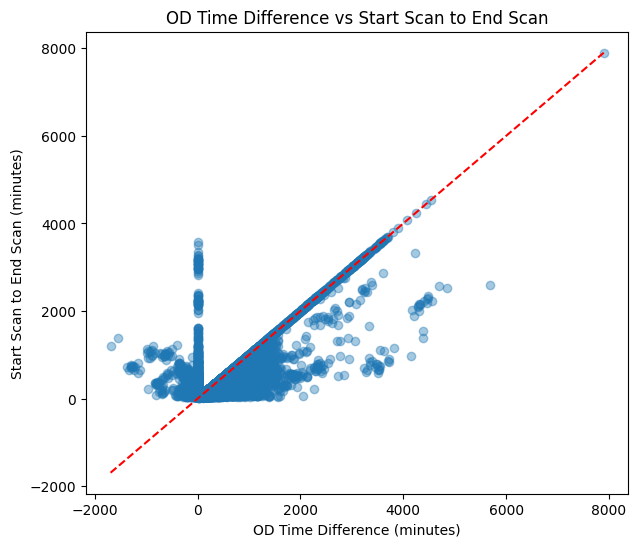

In [45]:
plt.figure(figsize=(7,6))

plt.scatter(
    trip_df["od_time_diff"],
    trip_df["start_scan_to_end_scan"],
    alpha=0.4
)

plt.plot(
    [trip_df["od_time_diff"].min(), trip_df["od_time_diff"].max()],
    [trip_df["od_time_diff"].min(), trip_df["od_time_diff"].max()],
    color="red",
    linestyle="--"
)

plt.title("OD Time Difference vs Start Scan to End Scan")
plt.xlabel("OD Time Difference (minutes)")
plt.ylabel("Start Scan to End Scan (minutes)")

plt.show()

**Histogram of the Differences**

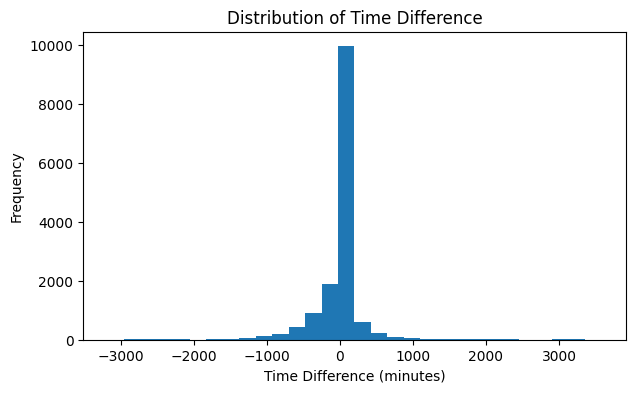

In [46]:
plt.figure(figsize=(7,4))

plt.hist(trip_df["time_difference"], bins=30)

plt.title("Distribution of Time Difference")
plt.xlabel("Time Difference (minutes)")
plt.ylabel("Frequency")

plt.show()

**Boxplot of the Differences**

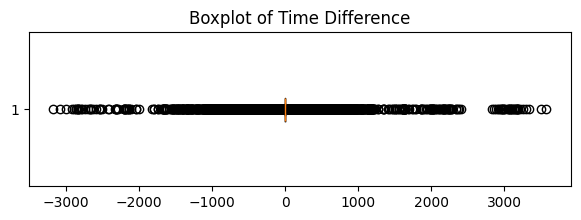

In [47]:
plt.figure(figsize=(7,2))

plt.boxplot(
    trip_df["time_difference"],
    vert=False
)

plt.title("Boxplot of Time Difference")

plt.show()

# 1. Scatter Plot: OD Time Difference vs Start Scan to End Scan

### Insights

* The scatter plot shows a **positive relationship** between `od_time_diff` and `start_scan_to_end_scan`.
* Many points lie close to the **red diagonal line**, indicating that the two time measurements are similar for many trips.
* However, several points are scattered away from the diagonal, showing noticeable differences between the two recorded times.
* These differences may be caused by **scan delays, operational delays, or differences in how the two time metrics are recorded**.

# 2. Histogram of Time Difference

### Insights

* The distribution of **time_difference** is highly concentrated around **0 minutes**.
* This indicates that, for most trips, `od_time_diff` and `start_scan_to_end_scan` are very similar.
* The distribution also contains both positive and negative values, showing that either measurement can be larger depending on the trip.
* A few extreme values on both sides indicate the presence of **outliers**.

# 3. Boxplot of Time Difference

### Insights

* The median time difference is **close to zero**, indicating that the two measurements generally agree.
* The boxplot shows **many outliers** on both the positive and negative sides.
* These outliers suggest that some trips have unusually large differences between the recorded trip durations.
* Such differences may be due to data recording issues, delayed scans, or exceptional operational conditions.

# 4. Hypothesis Test

### Results

* **T-statistic:** 10.99
* **P-value:** 5.54 × 10⁻²⁸

### Insights

* Since the **p-value is much smaller than 0.05**, the null hypothesis is rejected.
* This indicates that there is a **statistically significant difference** between `od_time_diff` and `start_scan_to_end_scan`.
* Although many trips have similar values, the overall difference across all trips is statistically significant.

# Overall Observation

* Both time measurements are **strongly related**, but they are **not identical**.
* Most trips show only a small difference between the two measures, indicating good consistency in recording trip durations.
* However, the presence of many outliers and the significant hypothesis test result suggest that there are systematic differences for some trips.
* Delhivery may need to further investigate trips with large time differences to identify possible causes such as delayed scanning, operational delays, or inconsistencies in data recording.


**Check Missing Values After Aggregation**

In [48]:
trip_df.isnull().sum()

,0
trip_uuid,0
data,0
route_type,0
source_center,0
source_name,0
destination_center,0
destination_name,0
trip_creation_time,0
od_start_time,0
od_end_time,0


**Detect Outliers Using Boxplots**

In [49]:
numeric_cols = trip_df.select_dtypes(include=["int64","float64"]).columns

print(numeric_cols)

Index(['start_scan_to_end_scan', 'actual_distance_to_destination',
       'actual_time', 'osrm_time', 'osrm_distance', 'segment_actual_time',
       'segment_osrm_time', 'segment_osrm_distance', 'od_time_diff',
       'time_difference'],
      dtype='object')


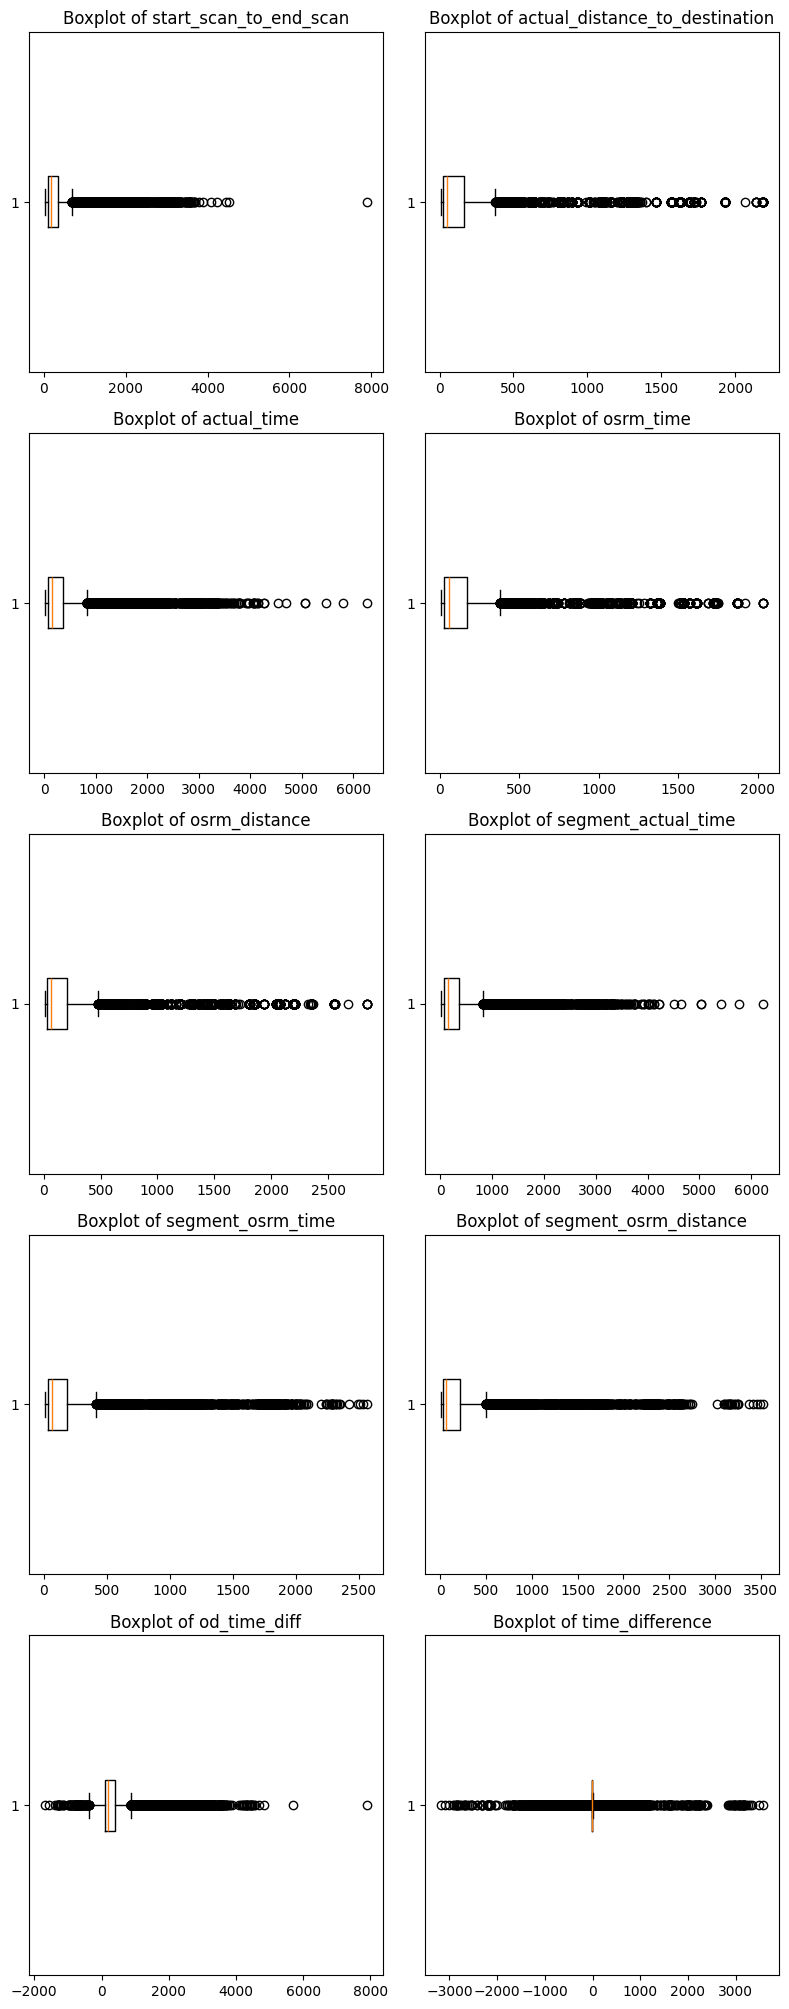

In [50]:
fig, axes = plt.subplots(len(numeric_cols), 2,
                         figsize=(8, 4*len(numeric_cols)))

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(trip_df[col], vert=False)
    axes[i].set_title(f"Boxplot of {col}")


for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

# 1. `start_scan_to_end_scan`

* The variable contains **many outliers** on the higher end.
* Most trips have shorter scan durations, while a few trips have exceptionally long durations.
* The distribution is positively skewed.

# 2. `actual_distance_to_destination`

* Most shipments travel relatively short distances.
* A large number of **high-distance outliers** are present.
* These outliers likely represent long-distance deliveries.

# 3. `actual_time`

* The majority of trips have moderate travel times.
* Several trips have extremely high travel times, appearing as outliers.
* This indicates variation in delivery duration across different routes.

# 4. `osrm_time`

* Estimated travel times also contain many outliers.
* Most estimated times are concentrated within a lower range.
* A few long-distance trips have much higher estimated travel times.

# 5. `osrm_distance`

* Most estimated route distances are relatively small.
* Many high-distance outliers are visible, indicating long-haul shipments.
* The distribution is right-skewed.

# 6. `segment_actual_time`

* Most shipment segments are completed within a short time.
* Many extreme outliers are observed, representing unusually long segment durations.
* These may be caused by operational delays or exceptional routes.

# 7. `segment_osrm_time`

* Estimated segment times are mostly concentrated in a small range.
* A considerable number of high-value outliers are present.
* This indicates a few shipment segments require much longer travel times.

# 8. `segment_osrm_distance`

* Most shipment segments cover short distances.
* Long-distance shipment segments appear as outliers.
* The variable is positively skewed.

# 9. `od_time_diff`

* Most trips have moderate origin-to-destination durations.
* Several large positive and negative outliers are present.
* These extreme values may indicate recording differences or unusual delivery conditions.

# 10. `time_difference`

* The median is close to **zero**, showing that the two time measurements generally agree.
* The boxplot contains outliers on both the positive and negative sides.
* This suggests that while most trips have similar recorded durations, some trips have substantial differences.

# Overall Observation

* **All numerical variables contain outliers**, which is common in logistics datasets due to long-distance deliveries, traffic delays, and operational variations.
* Most variables are **positively (right) skewed**, with the majority of observations concentrated at lower values and a few extremely high values.


**Remove Outliers Using IQR Method**

In [51]:
print("Rows Before Removing Outliers:", len(trip_df))

Rows Before Removing Outliers: 14817


In [52]:
iqr_cols = [
    "start_scan_to_end_scan",
    "actual_distance_to_destination",
    "actual_time",
    "osrm_time",
    "osrm_distance"
]

In [53]:
trip_df_clean = trip_df.copy()

mask = pd.Series(True, index=trip_df_clean.index)

for col in iqr_cols:

    Q1 = trip_df_clean[col].quantile(0.25)
    Q3 = trip_df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask &= trip_df_clean[col].between(lower, upper)

trip_df_clean = trip_df_clean[mask]

print(len(trip_df_clean))

12492


**Insight**

*The IQR (Interquartile Range) method was applied to the key numerical variables to identify and remove extreme observations.
*Rows with values outside the acceptable IQR range were removed.
*The dataset size reduced from `14,817 trips` to `12,492 trips`, indicating that approximately `15.7% of the trips were identified as outliers`.
*Most of the removed observations represent extreme values in travel time or distance. While some may correspond to genuine long-distance shipments, removing these extreme values helps reduce the influence of unusual observations and makes the dataset more suitable for statistical analysis and predictive modeling.
*The final cleaned dataset contains 12,492 trip-level records, which closely matches the expected size after outlier treatment. This indicates that the preprocessing steps were performed correctly and the data is ready for further analysis and modeling


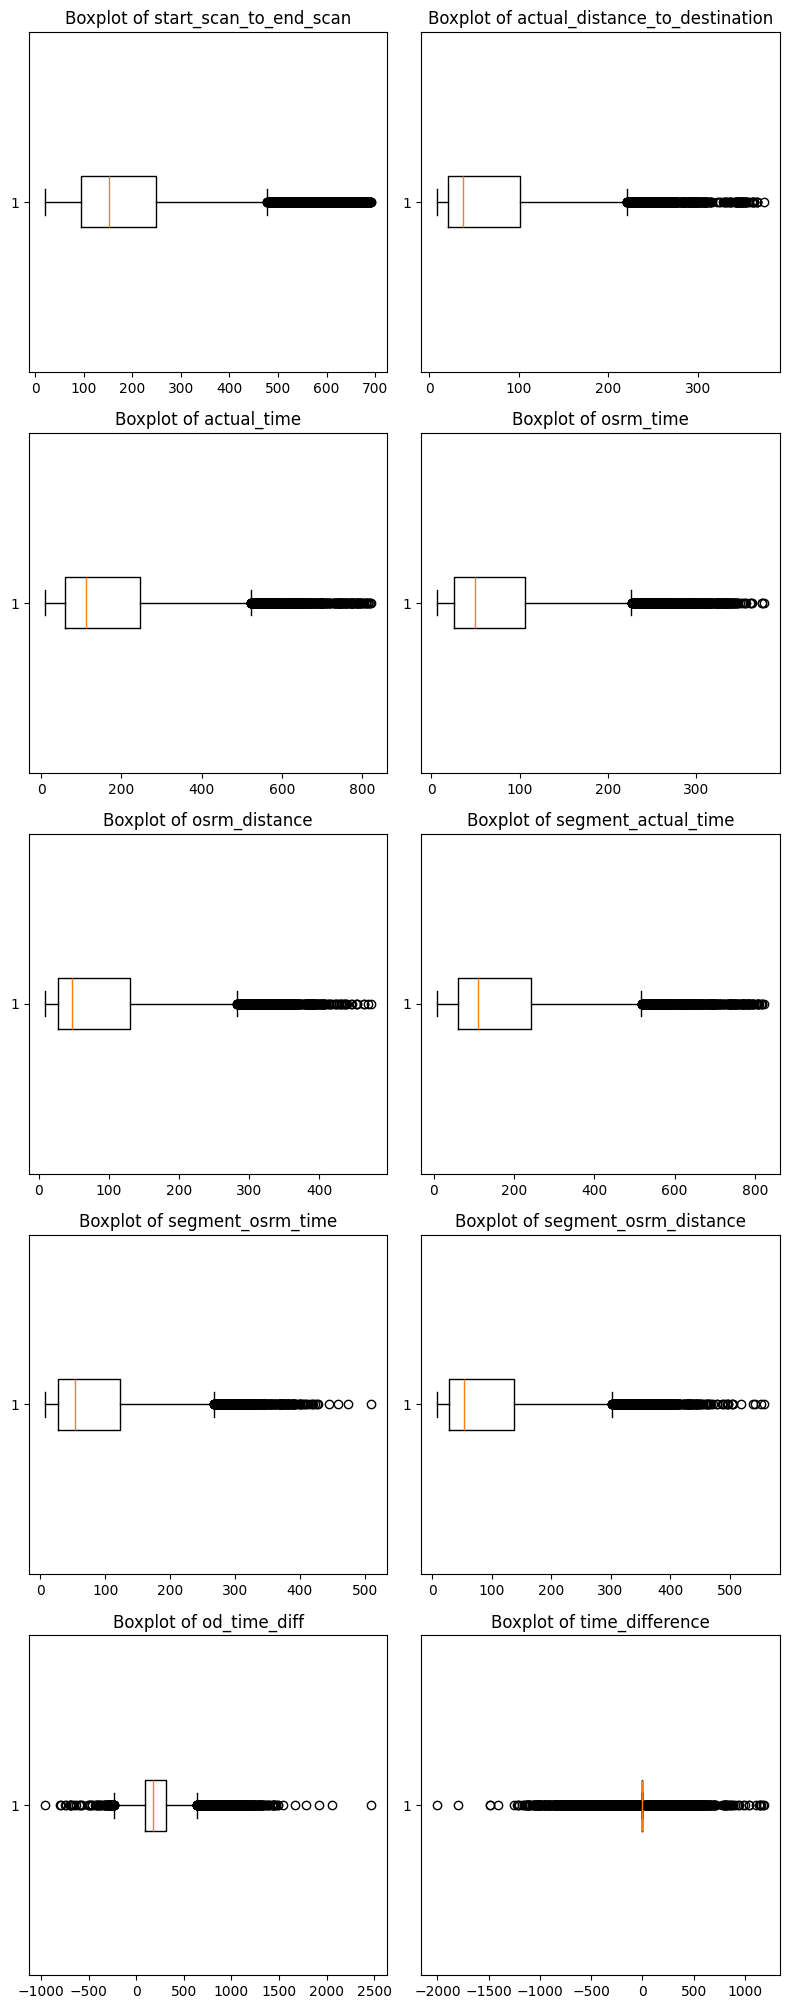

In [54]:
fig, axes = plt.subplots(len(numeric_cols), 2,
                         figsize=(8, 4*len(numeric_cols)))

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(trip_df_clean[col], vert=False)
    axes[i].set_title(f"Boxplot of {col}")


for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

In [55]:
trip_df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
trip_creation_time,12492,2018-09-22 14:01:09.638898176,2018-09-12 00:00:22.886430,2018-09-17 03:55:14.922288128,2018-09-22 05:21:49.138391552,2018-09-27 21:38:28.000818176,2018-10-03 23:59:42.701692,NaN
od_start_time,12492,2018-09-22 15:40:08.418889216,2018-09-12 00:01:00.113710,2018-09-17 05:59:46.747862272,2018-09-22 06:29:54.021157376,2018-09-27 23:21:20.805716736,2018-10-04 20:15:07.233819,NaN
od_end_time,12492,2018-09-22 19:25:53.919183360,2018-09-12 00:50:10.814399,2018-09-17 09:21:39.027330816,2018-09-22 10:16:21.164293376,2018-09-28 02:49:46.773472256,2018-10-05 01:07:04.463198,NaN
start_scan_to_end_scan,12492.0,192.396894,20.0,95.0,151.0,248.0,692.0,134.331053
actual_distance_to_destination,12492.0,71.124953,9.002461,21.301179,37.596388,101.000114,373.441224,71.208144
actual_time,12492.0,173.866555,9.0,60.0,112.0,245.0,823.0,154.656755
osrm_time,12492.0,77.452129,7.0,26.0,49.0,106.0,376.0,71.890542
osrm_distance,12492.0,90.26638,9.0729,28.1691,47.38495,130.088275,474.1337,88.546552
segment_actual_time,12492.0,172.232949,9.0,60.0,111.0,243.0,822.0,153.610259
segment_osrm_time,12492.0,85.098463,7.0,27.0,53.0,123.0,510.0,79.788649


#Insights

## Boxplot Observations

### 1. `start_scan_to_end_scan`

* Most extreme scan duration outliers have been removed.
* The remaining observations are concentrated within a smaller range.
* A few mild outliers still exist but are much less extreme.

### 2. `actual_distance_to_destination`

* Long-distance shipment outliers have been considerably reduced.
* Most deliveries now fall within a reasonable distance range.
* The distribution is less skewed than before.

### 3. `actual_time`

* Extreme travel time values have been removed.
* The majority of trips are now concentrated around the median.
* Only a few moderate outliers remain.

### 4. `osrm_time`

* Estimated travel times show fewer extreme values after treatment.
* The spread of the data has reduced significantly.
* The distribution appears more balanced.

### 5. `osrm_distance`

* Most unusually long estimated distances have been removed.
* The majority of shipments now lie within a narrower distance range.
* A small number of higher-distance observations still remain.

### 6. `segment_actual_time`

* Segment travel times are now more consistent.
* Most extreme delays have been removed.
* The remaining outliers are relatively moderate.

### 7. `segment_osrm_time`

* Estimated segment travel times have fewer extreme observations.
* The distribution is more compact compared to the original dataset.

### 8. `segment_osrm_distance`

* Segment distance values are concentrated within a reasonable range.
* Only a few higher-distance segments remain as outliers.

### 9. `od_time_diff`

* The origin-to-destination travel time shows fewer extreme values.
* Some positive and negative outliers remain, indicating a few trips still have unusually high or low recorded durations.

### 10. `time_difference`

* The median remains close to **zero**, indicating good agreement between the two time measurements.
* The spread has reduced after outlier treatment.
* A few large positive and negative differences still exist but are much fewer than before.

# Summary Statistics - Insights

* The cleaned dataset contains **12,492 trips**, making it more suitable for further analysis and predictive modeling.
* The **average actual trip time** is **174 minutes**, while the **average OSRM estimated time** is **77 minutes**, indicating that actual trips generally take longer than the estimated travel time.
* The **average actual travel distance** is **71 km**, while the **average OSRM estimated distance** is **90 km**.
* The median values are lower than the mean for most numerical variables, indicating that the data is still **slightly right-skewed**, although much less than before outlier treatment.
* The median **time difference** between `start_scan_to_end_scan` and `od_time_diff` is close to **zero** (-0.58 minutes), suggesting that the two measurements generally agree for most trips.
* The reduction in standard deviation across most variables indicates that removing extreme observations has made the dataset more consistent while preserving the overall business patterns.

# Overall Observation

* The IQR method successfully reduced the influence of extreme observations without removing a large portion of the dataset.
* Although a few mild outliers remain, this is expected in logistics data because some shipments naturally involve longer travel distances and durations.
* The cleaned dataset is more reliable for statistical analysis and machine learning while still preserving realistic business scenarios.


# Compare `actual_time` vs `osrm_time`

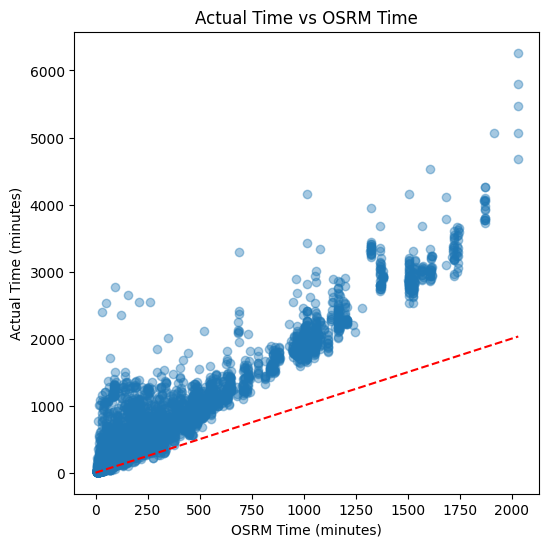

In [56]:
plt.figure(figsize=(6,6))

plt.scatter(trip_df["osrm_time"],
            trip_df["actual_time"],
            alpha=0.4)

plt.plot([0, trip_df["osrm_time"].max()],
         [0, trip_df["osrm_time"].max()],
         color="red",
         linestyle="--")

plt.title("Actual Time vs OSRM Time")
plt.xlabel("OSRM Time (minutes)")
plt.ylabel("Actual Time (minutes)")

plt.show()

In [57]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(
    trip_df["actual_time"],
    trip_df["osrm_time"]
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Actual time and OSRM time are statistically different.")
else:
    print("Actual time and OSRM time are statistically similar.")

T-statistic: 76.61411942262393
P-value: 0.0
Actual time and OSRM time are statistically different.


**Compare `actual_time` vs `segment_actual_time`**

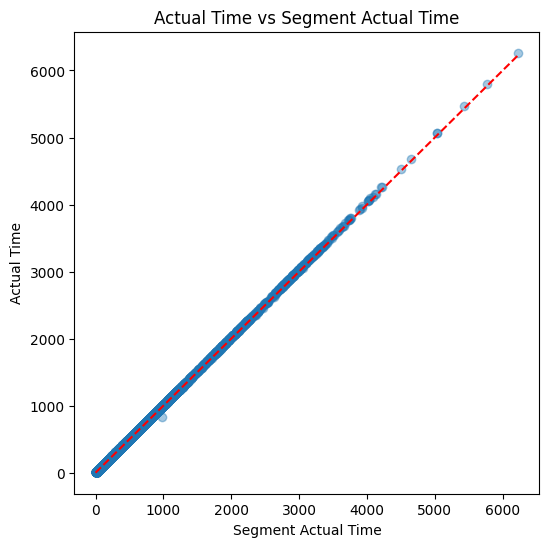

In [58]:
plt.figure(figsize=(6,6))

plt.scatter(trip_df["segment_actual_time"],
            trip_df["actual_time"],
            alpha=0.4)

plt.plot([0, trip_df["segment_actual_time"].max()],
         [0, trip_df["segment_actual_time"].max()],
         color="red",
         linestyle="--")

plt.title("Actual Time vs Segment Actual Time")
plt.xlabel("Segment Actual Time")
plt.ylabel("Actual Time")

plt.show()

In [59]:
t_stat, p_value = ttest_rel(
    trip_df["actual_time"],
    trip_df["segment_actual_time"]
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Actual time and Segment Actual time are statistically different.")
else:
    print("Actual time and Segment Actual time are statistically similar.")

T-statistic: 68.46429609754104
P-value: 0.0
Actual time and Segment Actual time are statistically different.


# Compare `osrm_distance` vs `segment_osrm_distance`

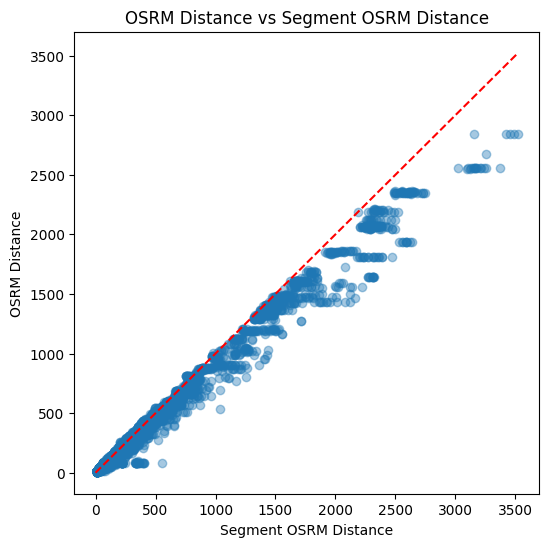

In [60]:
plt.figure(figsize=(6,6))

plt.scatter(trip_df["segment_osrm_distance"],
            trip_df["osrm_distance"],
            alpha=0.4)

plt.plot([0, trip_df["segment_osrm_distance"].max()],
         [0, trip_df["segment_osrm_distance"].max()],
         color="red",
         linestyle="--")

plt.title("OSRM Distance vs Segment OSRM Distance")
plt.xlabel("Segment OSRM Distance")
plt.ylabel("OSRM Distance")

plt.show()

In [61]:
t_stat, p_value = ttest_rel(
    trip_df["osrm_distance"],
    trip_df["segment_osrm_distance"]
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("OSRM Distance and Segment OSRM Distance are statistically different.")
else:
    print("OSRM Distance and Segment OSRM Distance are statistically similar.")

T-statistic: -37.381312117726914
P-value: 2.419297272724162e-292
OSRM Distance and Segment OSRM Distance are statistically different.


# Compare osrm_time vs segment_osrm_time

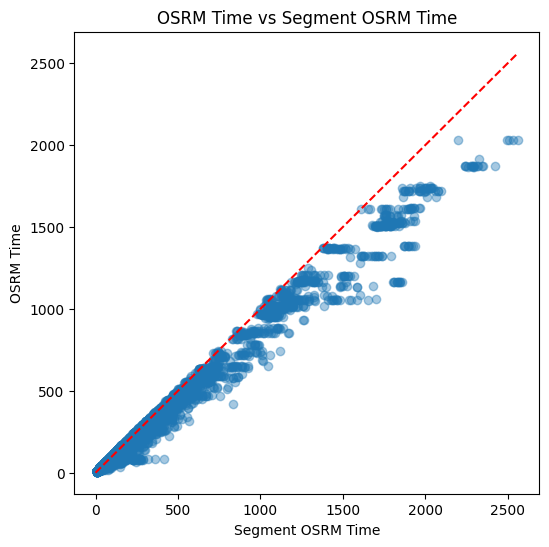

In [62]:
plt.figure(figsize=(6,6))

plt.scatter(trip_df["segment_osrm_time"],
            trip_df["osrm_time"],
            alpha=0.4)

plt.plot([0, trip_df["segment_osrm_time"].max()],
         [0, trip_df["segment_osrm_time"].max()],
         color="red",
         linestyle="--")

plt.title("OSRM Time vs Segment OSRM Time")
plt.xlabel("Segment OSRM Time")
plt.ylabel("OSRM Time")

plt.show()

In [63]:
t_stat, p_value = ttest_rel(
    trip_df["osrm_time"],
    trip_df["segment_osrm_time"]
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("OSRM Time and Segment OSRM Time are statistically different.")
else:
    print("OSRM Time and Segment OSRM Time are statistically similar.")

T-statistic: -43.37186612146427
P-value: 0.0
OSRM Time and Segment OSRM Time are statistically different.


# Correlation Analysis

In [64]:
print("Actual Time vs OSRM Time:",
      trip_df["actual_time"].corr(trip_df["osrm_time"]))

print("Actual Time vs Segment Actual Time:",
      trip_df["actual_time"].corr(trip_df["segment_actual_time"]))

print("OSRM Distance vs Segment OSRM Distance:",
      trip_df["osrm_distance"].corr(trip_df["segment_osrm_distance"]))

print("OSRM Time vs Segment OSRM Time:",
      trip_df["osrm_time"].corr(trip_df["segment_osrm_time"]))

Actual Time vs OSRM Time: 0.9585932709318203
Actual Time vs Segment Actual Time: 0.9999889281622261
OSRM Distance vs Segment OSRM Distance: 0.9947096182676257
OSRM Time vs Segment OSRM Time: 0.9932590034708527


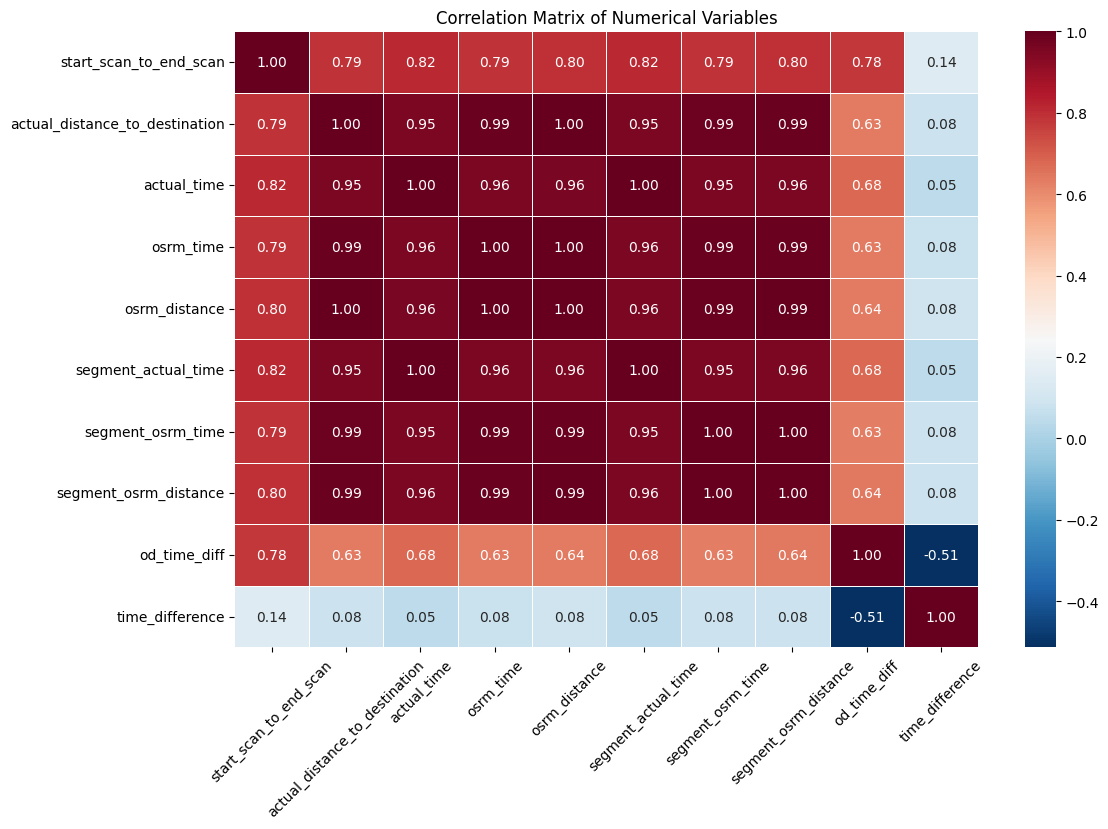

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = trip_df.select_dtypes(include=["int64", "float64"])

corr = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

# Insights

* **Actual Time vs OSRM Time:** Strong correlation, but **OSRM generally underestimates actual delivery time**.
* **Actual Time vs Segment Actual Time:** Very strong agreement, showing that segment times accurately represent the total trip duration.
* **OSRM Distance vs Segment OSRM Distance:** Highly consistent across trip and segment levels.
* **OSRM Time vs Segment OSRM Time:** Also highly consistent, with only small differences.

Overall, the analysis indicates that **segment-level aggregations are reliable and consistent with trip-level values**, demonstrating good data quality. However, **OSRM travel time estimates are consistently lower than actual delivery times**, suggesting that Delhivery's routing estimates could be improved by incorporating real-world operational delays such as traffic, loading/unloading, and waiting times.


# Identify Categorical Columns and Perform One-Hot Encoding

In [66]:
categorical_cols = trip_df_clean.select_dtypes(include=["object", "category"]).columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['trip_uuid', 'data', 'route_type', 'source_center', 'source_name',
       'destination_center', 'destination_name'],
      dtype='object')


# Perform One-Hot Encoding

In [67]:
trip_encoded = pd.get_dummies(
    trip_df_clean,
    columns=["route_type"],
    drop_first=True
)

In [68]:
print("Shape Before Encoding:", trip_df_clean.shape)

print("Shape After Encoding:", trip_encoded.shape)

Shape Before Encoding: (12492, 20)
Shape After Encoding: (12492, 20)


In [69]:
trip_encoded[["route_type_FTL"]].head()

,route_type_FTL
1,False
3,False
4,True
5,False
6,False


In [70]:
print(trip_encoded.columns)

Index(['trip_uuid', 'data', 'source_center', 'source_name',
       'destination_center', 'destination_name', 'trip_creation_time',
       'od_start_time', 'od_end_time', 'start_scan_to_end_scan',
       'actual_distance_to_destination', 'actual_time', 'osrm_time',
       'osrm_distance', 'segment_actual_time', 'segment_osrm_time',
       'segment_osrm_distance', 'od_time_diff', 'time_difference',
       'route_type_FTL'],
      dtype='object')


# Identify Numerical Columns and Apply StandardScaler

In [71]:
scale_cols = [
    "start_scan_to_end_scan",
    "actual_distance_to_destination",
    "actual_time",
    "osrm_time",
    "osrm_distance",
    "segment_actual_time",
    "segment_osrm_time",
    "segment_osrm_distance",
    "od_time_diff",
    "time_difference"
]

In [72]:
scaler = StandardScaler()

trip_scaled = trip_encoded.copy()

trip_scaled[scale_cols] = scaler.fit_transform(trip_scaled[scale_cols])

In [73]:
trip_scaled.head()

,trip_uuid,data,source_center,source_name,destination_center,destination_name,trip_creation_time,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,od_time_diff,time_difference,route_type_FTL
1,trip-153671042288605164,training,IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),2018-09-12 00:00:22.886430,2018-09-12 02:03:09.655591,2018-09-12 02:03:09.655591,-0.524076,0.028958,-0.199589,-0.131485,-0.058225,-0.203334,-0.251906,-0.131927,-0.991063,0.804470,False
3,trip-153671046011330457,training,IND400072AAB,Mumbai Hub (Maharashtra),IND401104AAA,Mumbai_MiraRd_IP (Maharashtra),2018-09-12 00:01:00.113710,2018-09-12 00:01:00.113710,2018-09-12 01:41:29.809822,-0.687857,-0.757664,-0.742749,-0.868746,-0.797199,-0.737174,-0.866053,-0.814209,-0.549897,0.170185,False
4,trip-153671052974046625,training,IND583101AAA,Bellary_Dc (Karnataka),IND583119AAA,Sandur_WrdN1DPP_D (Karnataka),2018-09-12 00:02:09.740725,2018-09-12 00:02:09.740725,2018-09-12 03:54:43.114421,-0.836749,0.791002,1.080717,0.550134,0.638395,1.092204,0.374774,0.532211,0.029842,-0.617197,True
5,trip-153671055416136166,training,IND600056AAA,Chennai_Poonamallee (Tamil Nadu),IND600056AAA,Chennai_Poonamallee (Tamil Nadu),2018-09-12 00:02:34.161600,2018-09-12 02:12:10.755603,2018-09-12 02:12:10.755603,-0.471964,-0.653433,-0.729817,-0.757461,-0.702502,-0.730664,-0.778318,-0.727343,-0.991063,0.840717,False
6,trip-153671066201138152,training,IND600044AAD,Chennai_Chrompet_DPC (Tamil Nadu),IND600048AAA,Chennai_Vandalur_Dc (Tamil Nadu),2018-09-12 00:04:22.011653,2018-09-12 00:04:22.011653,2018-09-12 01:42:22.349694,-0.702746,-0.871065,-0.969066,-0.896567,-0.883729,-0.965032,-0.903654,-0.897575,-0.560825,0.172718,False


In [74]:
trip_scaled[scale_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
start_scan_to_end_scan,12492.0,-1.933914e-17,1.00004,-1.283425,-0.725080,-0.308183,0.413942,3.719342
actual_distance_to_destination,12492.0,2.730231e-17,1.00004,-0.872442,-0.699720,-0.470872,0.419564,4.245699
actual_time,12492.0,-4.777905e-17,1.00004,-1.066059,-0.736283,-0.400041,0.459962,4.197420
osrm_time,12492.0,-7.280617e-17,1.00004,-0.980031,-0.715730,-0.395786,0.397118,4.152978
osrm_distance,12492.0,2.047674e-17,1.00004,-0.916995,-0.701323,-0.484301,0.449746,4.335377
segment_actual_time,12492.0,-7.735656e-17,1.00004,-1.062686,-0.730664,-0.398641,0.460711,4.230141
segment_osrm_time,12492.0,-6.939338e-17,1.00004,-0.978856,-0.728184,-0.402310,0.475043,5.325551
segment_osrm_distance,12492.0,-1.353740e-16,1.00004,-0.928823,-0.714836,-0.460846,0.444176,4.887342
od_time_diff,12492.0,5.687982e-17,1.00004,-5.202130,-0.576801,-0.208604,0.381600,9.845938
time_difference,12492.0,-1.706395e-18,1.00004,-10.183339,0.167742,0.169740,0.171718,6.303078


In [75]:
trip_scaled[scale_cols].mean()

,0
start_scan_to_end_scan,-1.933914e-17
actual_distance_to_destination,2.730231e-17
actual_time,-4.777905e-17
osrm_time,-7.280617e-17
osrm_distance,2.047674e-17
segment_actual_time,-7.735656e-17
segment_osrm_time,-6.939338e-17
segment_osrm_distance,-1.353740e-16
od_time_diff,5.687982e-17
time_difference,-1.706395e-18


In [76]:
trip_scaled[scale_cols].std()

,0
start_scan_to_end_scan,1.00004
actual_distance_to_destination,1.00004
actual_time,1.00004
osrm_time,1.00004
osrm_distance,1.00004
segment_actual_time,1.00004
segment_osrm_time,1.00004
segment_osrm_distance,1.00004
od_time_diff,1.00004
time_difference,1.00004


# Business Insight 1: High-Volume States and Cities

### Observation

* **Haryana, Karnataka, and Maharashtra** have the highest number of shipment origins and destinations.
* Major logistics hubs such as **Gurgaon (Haryana)**, **Bangalore (Karnataka)**, and **Bhiwandi (Maharashtra)** handle the largest shipment volumes.

### Business Recommendation

* Delhivery should continue strengthening its warehouse and distribution network in these locations.
* Increasing manpower and vehicle availability at these hubs can improve delivery speed and operational efficiency.

# Business Insight 2: Busiest Delivery Corridors

### Observation

* Shipment movement is concentrated between major logistics hubs such as **Gurgaon**, **Bangalore**, **Bhiwandi**, and **Hyderabad**.
* These corridors handle a significant share of total deliveries.

### Business Recommendation

* Delhivery should prioritize these high-volume corridors for route optimization, vehicle allocation, and capacity planning.
* Improving efficiency on these routes can significantly improve overall network performance.

# Business Insight 3: Distance and Delivery Time

### Observation

* Most deliveries are completed over **short to medium distances**, while only a small percentage are long-distance shipments.
* The average actual travel time is consistently higher than the estimated OSRM travel time.

### Business Recommendation

* Delivery estimates shared with customers should include additional buffer time for traffic and operational delays.
* More accurate delivery time predictions can improve customer satisfaction and reduce missed delivery expectations.

# Business Insight 4: FTL vs Carting Performance

### Observation

* **FTL (Full Truck Load)** accounts for the majority of shipments.
* FTL shipments generally cover longer distances and require more travel time than Carting shipments.
* Carting is mainly used for shorter-distance deliveries.

### Business Recommendation

* Continue using **FTL** for long-haul transportation and **Carting** for regional and last-mile deliveries.
* Optimizing vehicle utilization separately for each route type can improve operational efficiency and reduce transportation costs.

# Business Insight 5: OSRM Routing Accuracy

### Observation

* Actual delivery time is strongly correlated with OSRM estimated time, but hypothesis testing shows a statistically significant difference.
* In most cases, **actual delivery time is greater than OSRM estimated time**, indicating that the routing engine underestimates travel duration.
* Segment-level time and distance values closely match trip-level aggregated values, demonstrating good data consistency.

### Business Recommendation

* Delhivery should improve its ETA prediction model by incorporating factors such as traffic conditions, loading/unloading time, weather, and operational delays.
* More accurate delivery estimates can improve customer trust and operational planning.

# Overall Business Conclusion

* Delhivery has a strong logistics network concentrated around major industrial hubs such as **Haryana, Karnataka, and Maharashtra**.
* Most deliveries involve short and medium distances, while FTL shipments support long-distance transportation.
* The data shows good consistency between trip-level and segment-level records, indicating high data quality.
* However, OSRM consistently underestimates actual delivery time, highlighting an opportunity to improve route planning and estimated delivery times.
* By optimizing major delivery corridors, strengthening key logistics hubs, and enhancing ETA prediction models, Delhivery can improve operational efficiency, reduce delays, and provide a better customer experience.


Below are **5 simple, actionable recommendations** based on the above analysis.

# Recommendation 1: Improve Delivery Time Estimates

### What should Delhivery do?

Update the estimated delivery time shown to customers by including expected traffic and operational delays.

### Why?

The analysis showed that the **actual delivery time is consistently higher than the OSRM estimated time**, indicating that the current estimates are optimistic.

### Expected Impact

* More accurate delivery promises.
* Higher customer satisfaction.
* Fewer customer complaints about delayed deliveries.

# Recommendation 2: Strengthen Major Logistics Hubs

### What should Delhivery do?

Increase warehouse capacity, vehicles, and manpower in high-volume locations such as **Haryana, Maharashtra, and Karnataka**.

### Why?

These states and cities handled the highest number of shipments, making them the busiest parts of the logistics network.

### Expected Impact

* Faster order processing.
* Reduced congestion at major hubs.
* Improved overall delivery efficiency.

# Recommendation 3: Optimize High-Volume Delivery Corridors

### What should Delhivery do?

Allocate more vehicles and plan dedicated routes for the busiest source–destination corridors.

### Why?

The analysis showed that a large share of deliveries is concentrated on a few major corridors.

### Expected Impact

* Better vehicle utilization.
* Reduced delivery time.
* Lower transportation costs.

# Recommendation 4: Improve Resource Planning

### What should Delhivery do?

Schedule additional delivery staff and vehicles during peak operating hours and high-demand periods.

### Why?

The temporal analysis showed that delivery activity is higher during specific hours of the day, creating periods of increased workload.

### Expected Impact

* Faster package processing.
* Reduced delivery delays.
* Better workforce utilization.

# Recommendation 5: Continuously Improve Route Planning

### What should Delhivery do?

Regularly compare actual delivery performance with OSRM estimates and update routing rules based on real delivery data.

### Why?

Although OSRM distance estimates closely matched actual distances, the estimated travel time was consistently lower than the actual delivery time.

### Expected Impact

* More accurate route planning.
* Better delivery scheduling.
* Increased operational efficiency and customer trust.

# Overall Recommendation

Delhivery should focus on **improving delivery time predictions**, **strengthening major logistics hubs**, **optimizing busy delivery routes**, **planning resources according to demand**, and **continuously refining route estimates using actual delivery data**. These actions can reduce delays, improve operational efficiency, and enhance the overall customer experience.
